# Where does the extra low cloud in the KENDA-CH1 analysis come from?

## The problem

Total cloud cover from ICON-CH1 is biased too cloudy in the first hours of each forecast. Verified
against Swiss stations over autumn, the bias is about **+0.6 octa at lead time 1 h**, settling to
about **+0.15 octa by lead time 24 h**, decaying over roughly 4-6 hours.

The counter-intuitive part: the short-lead forecast is *better* on every other score = lower mean
absolute error, lower error standard deviation, higher correlation. Only the **bias** is worse. The
assimilation puts cloud in the right places at the right times while overdoing the amount.

This notebook asks **where in the hourly assimilation cycle the extra cloud enters**, using two
experiments that differ in exactly one setting:

- **801**: reference. Screen-level temperature and humidity (`T_2M`, `RH_2M`) are assimilated.
- **802**: identical in every other respect, with `T_2M` and `RH_2M` withheld.

Both are driven by the same initial and boundary conditions, so any difference between them is
attributable to that one setting.

## The files, and what each represents

Every hour the cycle repeats. The files it leaves behind are the stages of that loop:

| file | stage | valid at |
|---|---|---|
| `lff(T)` | **first guess**; the model's own 1 h forecast from the previous cycle, before new observations are used | T |
| `inc(T)` | **increment**; the correction derived from comparing first guess against observations. Corrections only, not a state | T |
| `lff(T)+inc(T)` | **analysis before increment application** (the raw analysis, identical to the archived `laf(T)`) | T |
| `iaf(T)` | **analysis after increment application**; the same increment fed in gradually over a 10-minute window rather than at once. The next forecast starts from this | T |
| `lff(T+1)` | **first guess of the next cycle**; one hour of model integration on from `iaf(T)` | T+1 |

The gradual-insertion window runs from T-5 min to T+5 min, centred on T. So `iaf(T)` already
contains about 10 minutes of model evolution on top of the increment, and the forecast producing
`lff(T+1)` is still being nudged for its first 5 of 60 minutes.

## The three steps this separates

```
lff(T) ──increment──▶ lff(T)+inc(T) ──analysis increment application──▶ iaf(T) ──one free hour──▶ lff(T+1)
        (no model)                  (~10 min model)          (~1 h model)
```

| step | computed as | model content |
|---|---|---|
| increment | `inc(T)` | **none**; purely observation-driven |
| analysis increment application | `iaf(T) - lff(T) - inc(T)` | gradual insertion + ~10 min |
| one free hour | `lff(T+1) - iaf(T)` | ~1 h |

**Sign convention throughout: positive means more cloud, more moisture, warmer.**

## 0. Setup

In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

import pickle
from datetime import datetime, timedelta
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import eccodes            # before earthkit.data: fixes native library resolution
import earthkit.data as ekd

SAVE_FIGURES = False     # write PNGs to OUTPUT_DIR
SHOW_FIGURES = True     # also draw them inline below each cell

if SAVE_FIGURES and not SHOW_FIGURES:
    matplotlib.use("Agg")

OUTPUT_DIR = Path("./figures/spindown_decomposition")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish(fig, name):
    """Save a figure and/or draw it inline."""
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

In [2]:
# ============================== what to analyse ==============================
EXP_IDS = ["801", "802"]
BASE_DIR_TMPL = "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}"
YEAR_SUFFIX = "25"

# On disk for both experiments: 2025-10-04 01 UTC .. 2025-10-10 00 UTC.
# DATE_END must leave lff(T+1) readable, so it cannot exceed 2025-10-10 00 UTC.
DATE_START = datetime(2025, 10, 4, 1)
DATE_END = datetime(2025, 10, 10, 0)

# Every Nth cycle. 1 = every hour; 3 keeps full diurnal coverage at a third of the cost.
CYCLE_STRIDE = 1

CYCLE_TIMES = pd.date_range(DATE_START, DATE_END, freq="1h").to_pydatetime().tolist()[::CYCLE_STRIDE]

# Parallel cycle reads. A worker holds one cycle (~few hundred MB); use 1 for clear tracebacks.
N_WORKERS = 16

# Every average and distribution below is over these cells, so all numbers share a region.
ANALYSIS_BOX = dict(lon=(5.9, 10.6), lat=(45.8, 47.9))
MAP_BOX = dict(lon=(5.3, 11.2), lat=(45.4, 48.3))     # wider, for map context

# ICON-CH1: 80 layers, 81 HHL interfaces, so the layer touching the ground is 80.
GROUND_LEVEL = 80
LEVELS_OF_INTEREST = list(range(40, 81))   # ground to mid troposphere

# Section line: the great circle through Payerne and St. Gallen, extended back past
# Payerne. Built this way so Payerne lies exactly on it (Geneva -> St. Gallen misses by 29 km).
PAYERNE = (46.8123, 6.9422)       # radiosonde site; (lat, lon)
SECTION_EAST = (47.4200, 9.3700)  # St. Gallen
SECTION_WEST_KM = 65.0            # how far back past Payerne the section starts
N_TRANSECT = 300
SECTION_ZTOP = 5000.0        # top of the vertical section [m above sea level]

print(f"{len(CYCLE_TIMES)} cycles per experiment, "
      f"{CYCLE_TIMES[0]:%Y-%m-%d %H} UTC to {CYCLE_TIMES[-1]:%Y-%m-%d %H} UTC"
      f"{'' if CYCLE_STRIDE == 1 else f', every {CYCLE_STRIDE}th hour'}")

144 cycles per experiment, 2025-10-04 01 UTC to 2025-10-10 00 UTC


In [3]:
# ============================ plotting conventions ============================
# Colour = experiment. Never used for anything else.
EXP_COLOUR = {"801": "#0072B2", "802": "#D55E00"}

# Line style = file. Identical styles for both experiments.
STAGES = ["lff", "laf", "iaf", "lff1"]
STAGE_STYLE = {
    "lff":  ("--",  "lff(T) = first guess"),
    "laf":  ("-",   "laf(T) = uninitialized ana"),
    "iaf":  ("-.",  "iaf(T) = initialized ana"),
    "lff1": (":",   "lff(T+1) = first guess, next cycle"),
}
TERMS = ["d_letkf", "d_settle", "d_free"]
TERM_STYLE = {
    "d_letkf":  ("-",  "inc(T) = assimilation increment"),
    "d_settle": ("--", "iaf(T) - lff(T) - inc(T) = analysis increment application"),
    "d_free":   (":",  "lff(T+1) - iaf(T) = one free hour"),
}

HEIGHT_LABEL = "height above ground [m]"


def period_tag(n_cycles):
    """Consistent period-and-sample-size string for every title."""
    return (f"{DATE_START:%d %b} - {DATE_END:%d %b %Y}, {n_cycles} cycles per experiment"
            + ("" if CYCLE_STRIDE == 1 else f" (every {CYCLE_STRIDE}th hour)"))


def style_legend(ax, styles, exps=EXP_IDS, **kw):
    """Legend in two parts: experiments (coloured), then file line styles (grey)."""
    handles = [Line2D([], [], color=EXP_COLOUR[e], ls="-", lw=2.6, label=f"{e}")
               for e in exps]
    handles += [Line2D([], [], color="0.25", ls=s, lw=1.6, label=lab) for s, lab in styles.values()]
    ax.legend(handles=handles, **kw)


def orient_vertical(ax, z):
    """Ground at the bottom, model top at the top. set_ylim, not invert_yaxis(), which
    toggles and so cancels itself out across shared axes."""
    ax.set_ylim(np.min(z), np.max(z))


def add_borders(ax):
    """Country borders, coastlines and lakes on a map axis."""
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.7, edgecolor="k")
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.5, edgecolor="k")
    ax.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="none",
                   edgecolor="0.35", linewidth=0.4)

### Reading the files

In [4]:
def file_path(exp_id, kind, time):
    """kind: "lff"/"iff" (first-guess archive) or "inc"/"iaf"/"laf" (analysis archive)."""
    base = BASE_DIR_TMPL.format(exp=exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time:%Y%m%d%H}")


CACHE_DIR = Path(f"/scratch/mch/{os.environ['USER']}/spindown_grib_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_index(path):
    """shortName -> [(level, byte offset, byte length), ...], sorted by level.

    Headers-only pass: records where each message sits without decoding any values. About
    1.3 s per file, against ~14 s for earthkit's own scan, which decodes everything.
    """
    index = {}
    with open(path, "rb") as f:
        while True:
            h = eccodes.codes_grib_new_from_file(f, headers_only=True)
            if h is None:
                break
            index.setdefault(eccodes.codes_get(h, "shortName"), []).append(
                (eccodes.codes_get_long(h, "level"),
                 eccodes.codes_get_message_offset(h),
                 eccodes.codes_get_long(h, "totalLength")))
            eccodes.codes_release(h)
    for entries in index.values():
        entries.sort()          # index 0 = highest level requested, last = nearest the ground
    return index


def load_index(path):
    """build_index, cached on disk. Key is (name, size, mtime), so a regenerated file
    invalidates its own entry."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    stat = os.stat(path)
    cached = CACHE_DIR / f"{Path(path).name}_{stat.st_size}_{stat.st_mtime_ns}.pkl"
    if cached.exists():
        with open(cached, "rb") as fh:
            return pickle.load(fh)
    index = build_index(path)
    tmp = cached.with_suffix(f".tmp{os.getpid()}")   # unique + atomic: workers run in parallel
    with open(tmp, "wb") as fh:
        pickle.dump(index, fh, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, cached)
    return index


_grid = None


def grid_lonlat(path):
    """Cell longitudes and latitudes, cached in an .npz.

    ecCodes cannot expand this unstructured grid's coordinates (the "latitudes" key
    raises), so one field goes through earthkit. All files share the same grid.
    """
    global _grid
    if _grid is not None:
        return _grid
    npz = CACHE_DIR / "icon_grid_lonlat.npz"
    if npz.exists():
        z = np.load(npz)
        _grid = (z["lon"], z["lat"])
    else:
        xa = ekd.from_source("file", path).to_fieldlist()[0].to_xarray()
        _grid = (xa["longitude"].values, xa["latitude"].values)
        np.savez(npz, lon=_grid[0], lat=_grid[1])
    return _grid


class Grib:
    """One GRIB file, indexed by variable name, decoding only the messages asked for.

    These files hold 1200-1500 messages; a cycle wants ~170. Reading by offset keeps the
    cost proportional to that rather than to the file size.
    """

    def __init__(self, path):
        self.path = path
        self.index = load_index(path)

    def _read(self, entries):
        values = []
        with open(self.path, "rb") as f:
            for _, offset, length in entries:
                f.seek(offset)
                h = eccodes.codes_new_from_message(f.read(length))
                values.append(eccodes.codes_get_values(h))
                eccodes.codes_release(h)
        return np.array([e[0] for e in entries]), np.stack(values)

    def profile(self, short_name, levels=None):
        """Multi-level field -> (levels, array of shape (n_levels, n_cells)).

        `levels` filters before anything is decoded, halving the read and the memory.
        """
        entries = self.index[short_name]
        if levels is not None:
            want = {int(lev) for lev in levels}
            entries = [e for e in entries if e[0] in want]
        return self._read(entries)

    def field(self, short_name):
        """Single-level field -> values."""
        return self._read(self.index[short_name][:1])[1][0]

    @property
    def lonlat(self):
        return grid_lonlat(self.path)


def in_box(lon, lat, box):
    return ((lon >= box["lon"][0]) & (lon <= box["lon"][1]) &
            (lat >= box["lat"][0]) & (lat <= box["lat"][1]))

## 1. Diurnal cycle of cloud cover over Switzerland
Each box summarises the distribution of cloud cover over the grid cells inside the Swiss box,
pooled across every day of the period at that hour. The spread therefore reflects both how variable
cloud is across the country and how much it varied from day to day. Boxes show the median and
quartiles, whiskers the 5th to 95th percentile.

In [5]:
CLOUD_VARS = ["CLCT", "CLCH", "CLCM", "CLCL"]   # total, then high to low, top-down
N_BOX_SAMPLE = 20000     # grid cells sampled per cycle; enough for stable quartiles


def cloud_samples(exp_id, t):
    """Cloud cover inside the analysis box for first guess and analysis at one cycle."""
    lff = Grib(file_path(exp_id, "lff", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lon, lat = lff.lonlat
    mask = in_box(lon, lat, ANALYSIS_BOX)
    idx_box = np.flatnonzero(mask)
    rng = np.random.default_rng(int(t.timestamp()) % (2**31))
    take = rng.choice(idx_box, size=min(N_BOX_SAMPLE, idx_box.size), replace=False)

    out = {"exp": exp_id, "time": t, "hour": t.hour, "n_box_cells": int(idx_box.size)}
    for var in CLOUD_VARS:
        v_lff, v_iaf = lff.field(var), iaf.field(var)
        out[(var, "lff", "sample")] = v_lff[take]
        out[(var, "iaf", "sample")] = v_iaf[take]
        out[(var, "lff", "mean")] = float(np.nanmean(v_lff[mask]))
        out[(var, "iaf", "mean")] = float(np.nanmean(v_iaf[mask]))
    return out


def cloud_samples_safe(exp_id, t):
    try:
        return cloud_samples(exp_id, t)
    except Exception as e:
        print(f"  skipped {exp_id} {t:%Y-%m-%d %H}: {e}")
        return None


jobs = [(e, t) for e in EXP_IDS for t in CYCLE_TIMES]
print(f"reading {len(jobs)} cycle-experiment combinations "
      f"(2 files each, {len(CLOUD_VARS)} messages per file)...")
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(cloud_samples_safe, e, t) for e, t in jobs]
    cloud_records = [f.result() for f in futures]
cloud_records = [r for r in cloud_records if r is not None]

n_cycles_cloud = len({r["time"] for r in cloud_records if r["exp"] == EXP_IDS[0]})
print(f"{len(cloud_records)} loaded; {n_cycles_cloud} cycles per experiment; "
      f"{cloud_records[0]['n_box_cells']} grid cells inside the Swiss box")

# domain-mean time series, for the overview figure
cloud_means = pd.DataFrame([
    {"exp": r["exp"], "time": r["time"], "hour": r["hour"],
     **{f"{v}_{s}": r[(v, s, "mean")] for v in CLOUD_VARS for s in ("lff", "iaf")}}
    for r in cloud_records]).sort_values(["exp", "time"]).reset_index(drop=True)
cloud_means.to_csv(OUTPUT_DIR / "cloud_cover_means.csv", index=False)

reading 288 cycle-experiment combinations (2 files each, 4 messages per file)...
288 loaded; 144 cycles per experiment; 80876 grid cells inside the Swiss box


In [6]:
# Pool the per-cycle samples by hour, keeping experiments and stages separate.
pooled = {}
for exp_id in EXP_IDS:
    for var in CLOUD_VARS:
        for stage in ("lff", "iaf"):
            for h in range(24):
                chunks = [r[(var, stage, "sample")] for r in cloud_records
                          if r["exp"] == exp_id and r["hour"] == h]
                pooled[(exp_id, var, stage, h)] = (np.concatenate(chunks) if chunks
                                                   else np.array([]))

hours_present = sorted({r["hour"] for r in cloud_records})
n_days = {h: sum(1 for r in cloud_records if r["exp"] == EXP_IDS[0] and r["hour"] == h)
          for h in hours_present}
print(f"hours covered: {hours_present[0]:02d}-{hours_present[-1]:02d} UTC, "
      f"{min(n_days.values())}-{max(n_days.values())} days per hour")


hours covered: 00-23 UTC, 6-6 days per hour


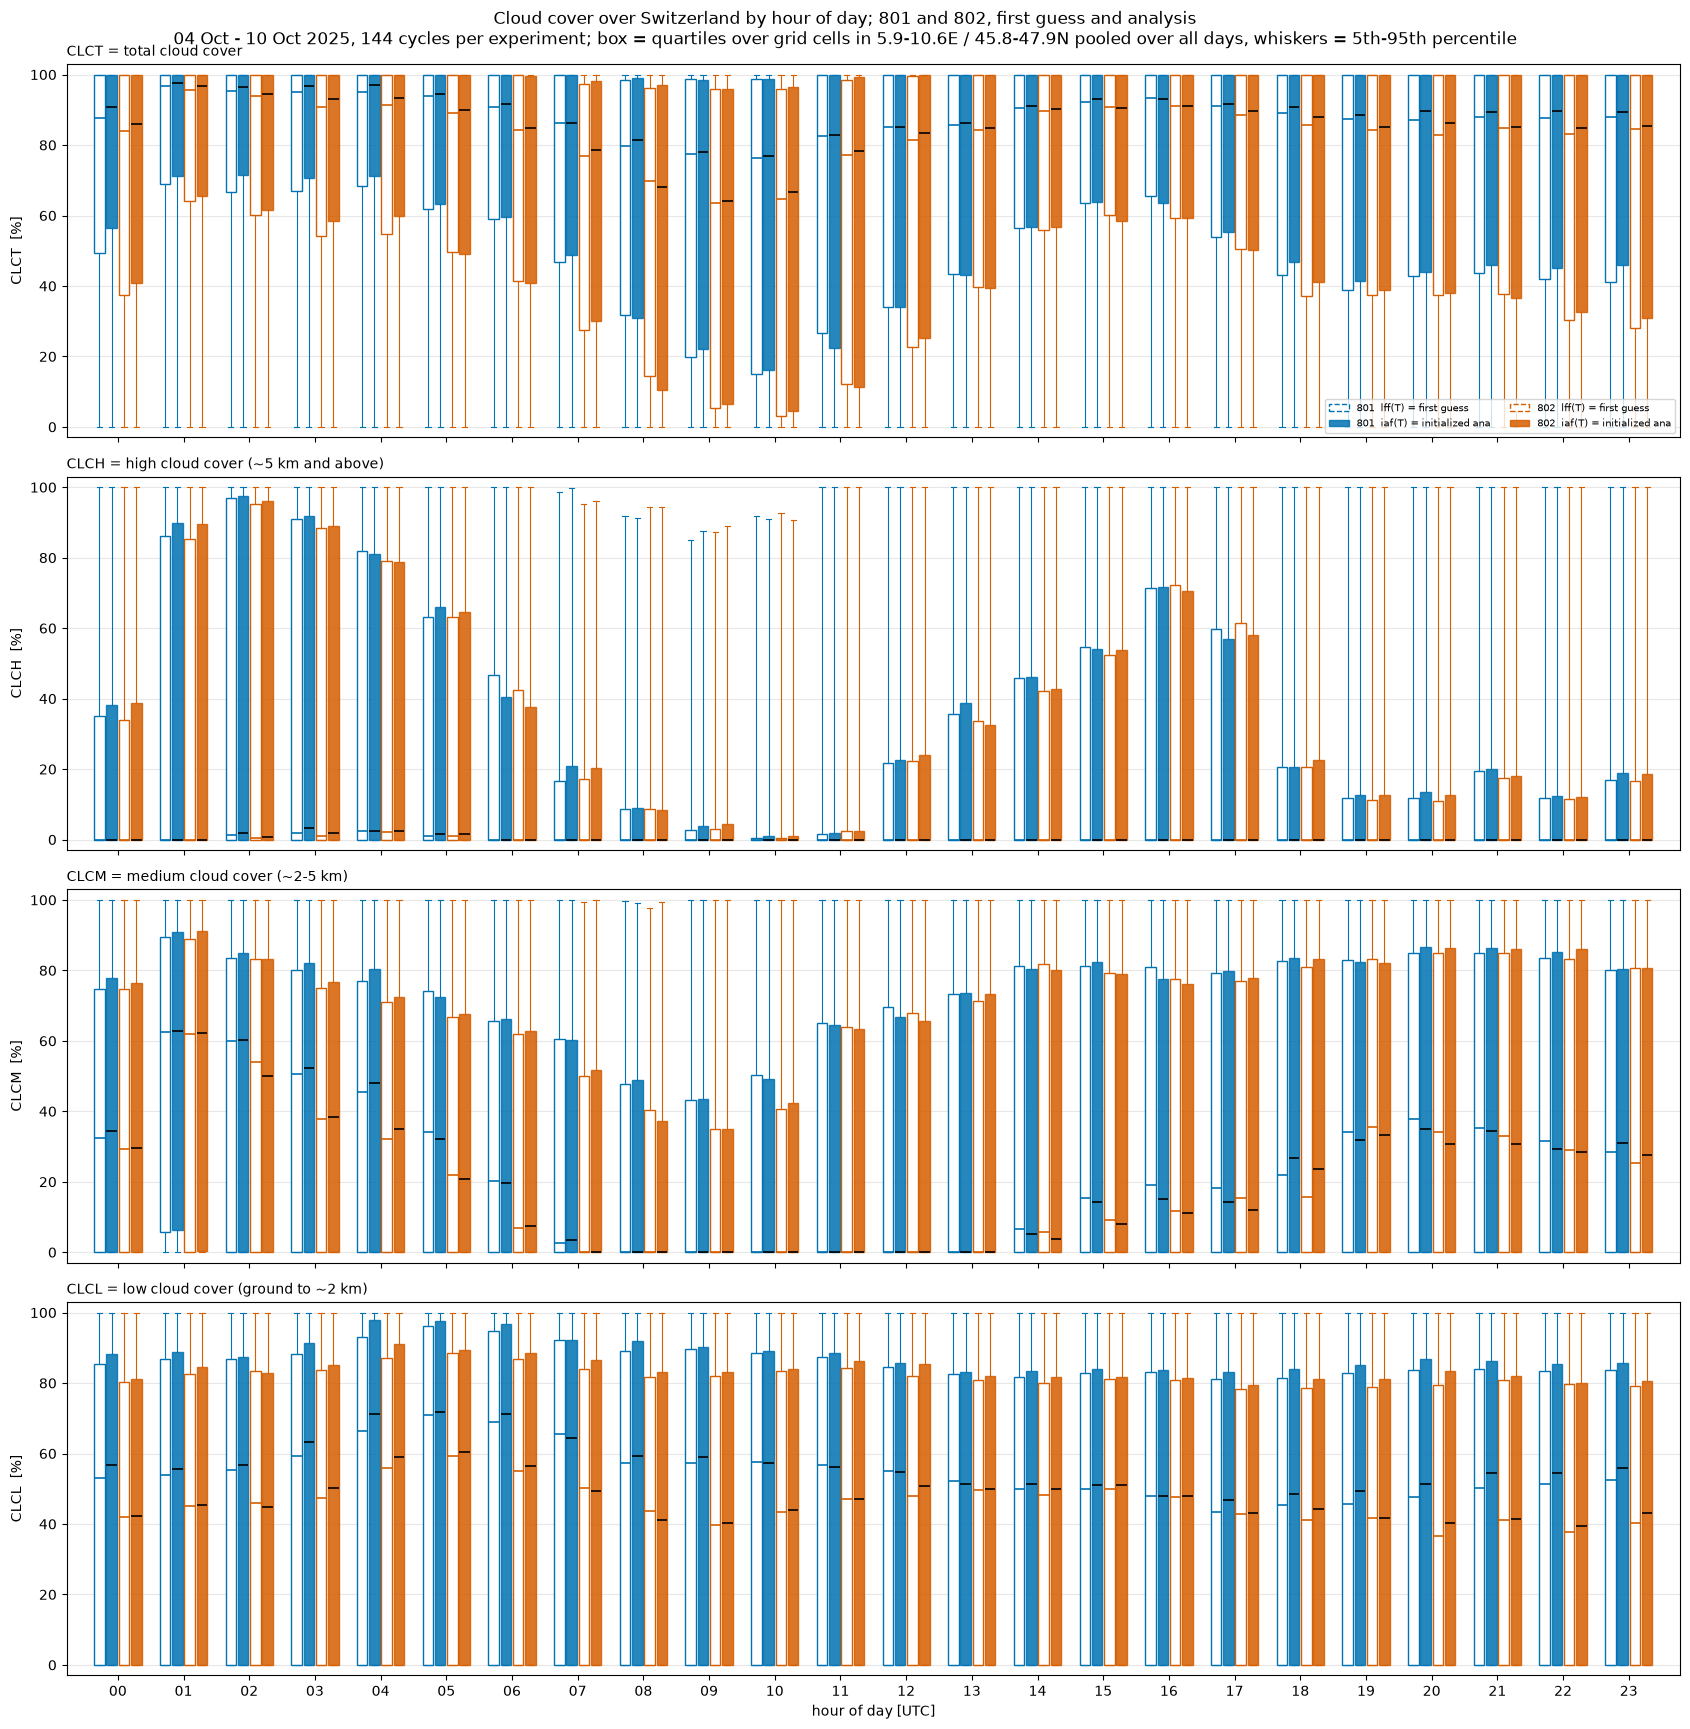

In [7]:
VAR_LONG = {"CLCT": "total cloud cover",
            "CLCH": "high cloud cover (~5 km and above)",
            "CLCM": "medium cloud cover (~2-5 km)",
            "CLCL": "low cloud cover (ground to ~2 km)"}

# Four boxes per hour: both experiments, each as first guess and analysis.
# Colour = experiment; filled = iaf(T) analysis, unfilled + dashed = lff(T) first guess.
BOX_SLOTS = [(e, s) for e in EXP_IDS for s in ("lff", "iaf")]
BOX_OFFSETS = np.linspace(-0.28, 0.28, len(BOX_SLOTS))

fig, axes = plt.subplots(len(CLOUD_VARS), 1, figsize=(17, 4.4 * len(CLOUD_VARS)),
                         sharex=True)
for ax, var in zip(axes, CLOUD_VARS):
    for h in hours_present:
        for (exp_id, stage), offset in zip(BOX_SLOTS, BOX_OFFSETS):
            data = pooled[(exp_id, var, stage, h)]
            if data.size == 0:
                continue
            colour = EXP_COLOUR[exp_id]
            filled = stage == "iaf"
            ax.boxplot(
                [data], positions=[h + offset], widths=0.16, whis=(5, 95),
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor=colour if filled else "white",
                              edgecolor=colour, linewidth=1.0,
                              linestyle="-" if filled else "--",
                              alpha=0.85 if filled else 1.0),
                medianprops=dict(color="k" if filled else colour, linewidth=1.2),
                whiskerprops=dict(color=colour, linewidth=0.8),
                capprops=dict(color=colour, linewidth=0.8))
    ax.set_ylabel(f"{var}  [%]")
    ax.set_title(f"{var} = {VAR_LONG[var]}", fontsize=10, loc="left")
    ax.grid(alpha=0.3, axis="y")
    ax.set_ylim(-3, 103)

axes[0].legend(handles=[
    Patch(facecolor=EXP_COLOUR[e] if s == "iaf" else "white", edgecolor=EXP_COLOUR[e],
          linestyle="-" if s == "iaf" else "--", alpha=0.85 if s == "iaf" else 1.0,
          label=f"{e}  {STAGE_STYLE[s][1]}") for e, s in BOX_SLOTS],
    loc="lower right", fontsize=7, ncol=2)

axes[-1].set_xticks(hours_present)
axes[-1].set_xticklabels([f"{h:02d}" for h in hours_present])
axes[-1].set_xlabel("hour of day [UTC]")
plt.suptitle("Cloud cover over Switzerland by hour of day; 801 and 802, first guess and analysis"
             f"\n{period_tag(n_cycles_cloud)}; "
             f"box = quartiles over grid cells in {ANALYSIS_BOX['lon'][0]}-"
             f"{ANALYSIS_BOX['lon'][1]}E / {ANALYSIS_BOX['lat'][0]}-{ANALYSIS_BOX['lat'][1]}N "
             f"pooled over all days, whiskers = 5th-95th percentile")
plt.tight_layout()
finish(fig, "diurnal_boxplots.png")

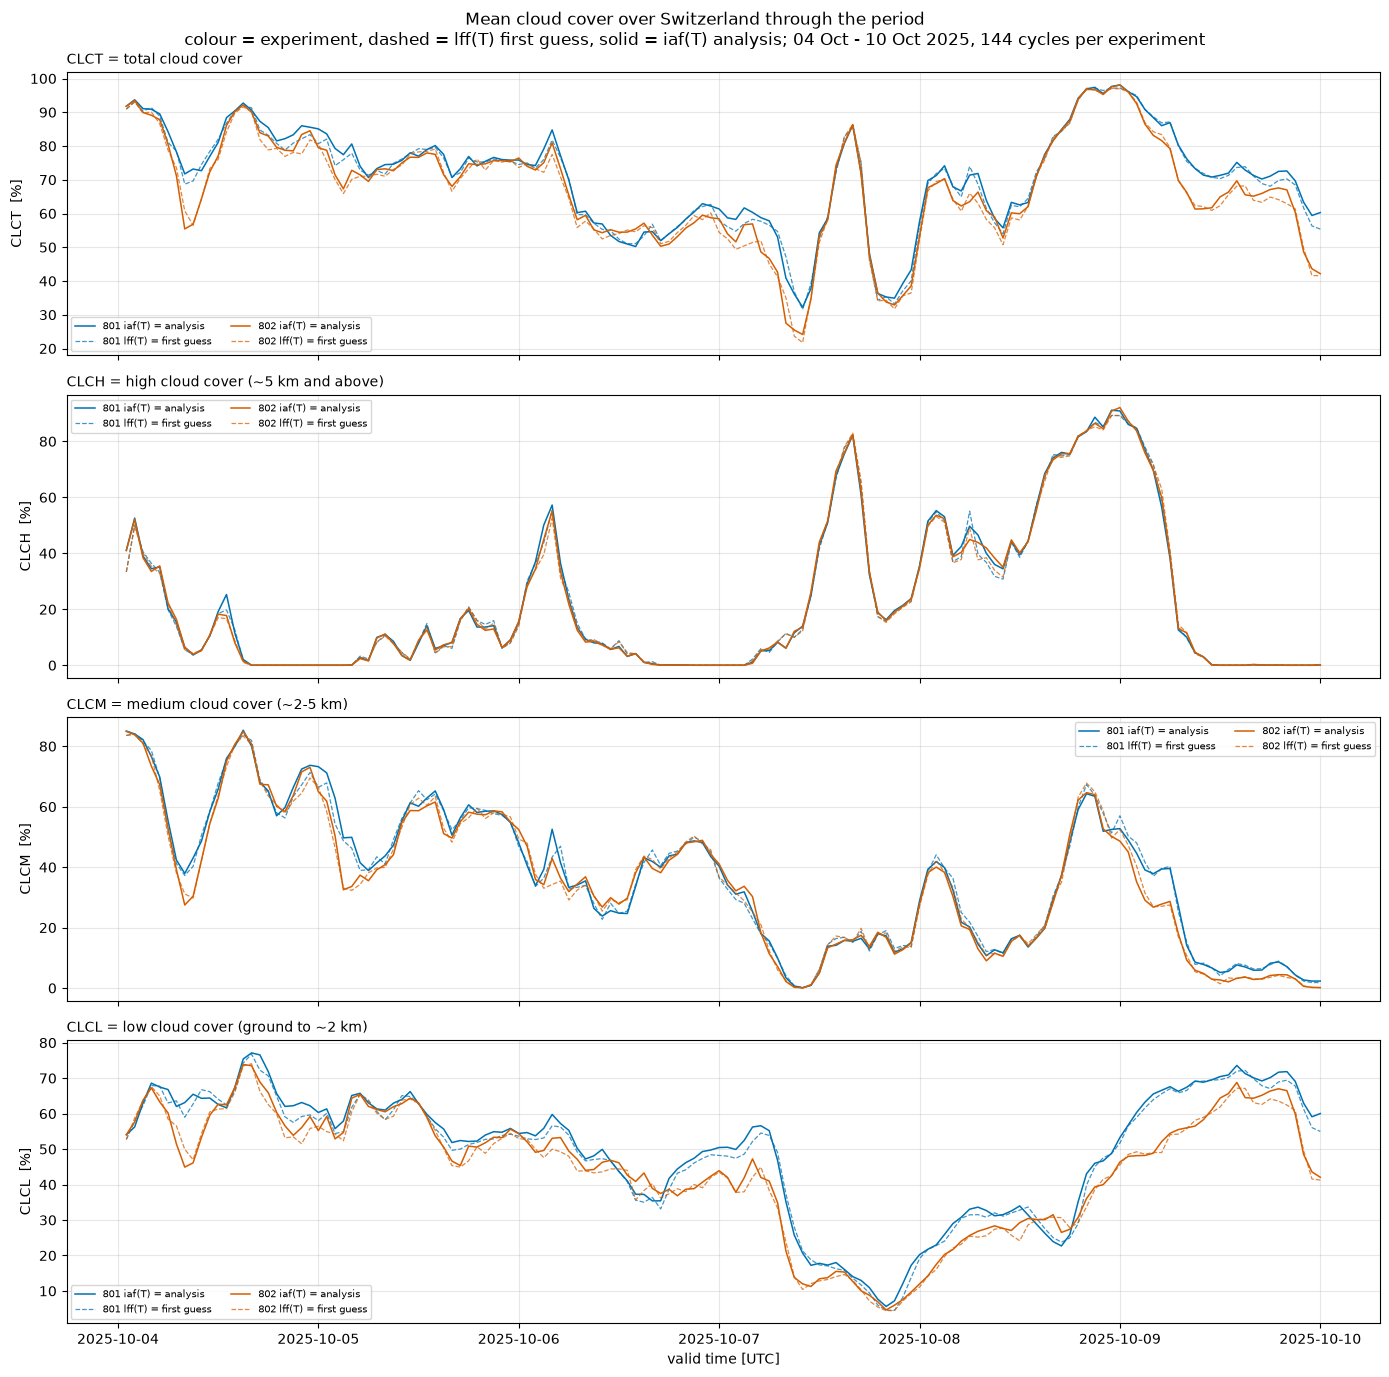

In [8]:
# Difference between the two experiments through the period, as a sanity view of when they diverge.
fig, axes = plt.subplots(len(CLOUD_VARS), 1, figsize=(14, 3.5 * len(CLOUD_VARS)),
                         sharex=True)
for ax, var in zip(axes, CLOUD_VARS):
    for exp_id in EXP_IDS:
        sub = cloud_means[cloud_means["exp"] == exp_id]
        ax.plot(sub["time"], sub[f"{var}_iaf"], "-", color=EXP_COLOUR[exp_id], lw=1.1,
                label=f"{exp_id} iaf(T) = analysis")
        ax.plot(sub["time"], sub[f"{var}_lff"], "--", color=EXP_COLOUR[exp_id], lw=0.9,
                alpha=0.75, label=f"{exp_id} lff(T) = first guess")
    ax.set_ylabel(f"{var}  [%]")
    ax.set_title(f"{var} = {VAR_LONG[var]}", fontsize=10, loc="left")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
axes[-1].set_xlabel("valid time [UTC]")
plt.suptitle(f"Mean cloud cover over Switzerland through the period\n"
             f"colour = experiment, dashed = lff(T) first guess, solid = iaf(T) analysis; "
             f"{period_tag(n_cycles_cloud)}")
plt.tight_layout()
finish(fig, "cloud_cover_timeseries.png")


## 2. Temperature, water vapour and cloud water through the cycle

In [9]:
DIAG_VARS = ["T", "QV", "QC"]
# Cloud fraction is a state, not an increment: CLC is present in the model-state files
# lff(T) and iaf(T) but in neither inc(T) nor laf(T), so the cycle can only be split into
# "before the assimilation" and "after it, once the model has run 10 minutes on the
# increment". There is no CLC stage in between to attribute the change to.
CLC_STAGES = ["lff", "iaf"]
VAR_UNITS = {"T": "K", "QV": "kg/kg", "QC": "kg/kg", "RH": "%"}
PLOT_VARS = DIAG_VARS + ["RH"]


def saturation_qv(T_k, p_pa):
    """Saturation specific humidity from temperature [K] and pressure [Pa] (Tetens, over water)."""
    T_c = T_k - 273.15
    e_s = 611.2 * np.exp(17.62 * T_c / (243.12 + T_c))
    return 0.622 * e_s / np.clip(p_pa - 0.378 * e_s, 1.0, None)


def cycle_states(exp_id, t, sel, levels=LEVELS_OF_INTEREST):
    """The four states and three steps of one cycle, for T, QV, QC and derived RH.

    `sel` fixes which cells survive the read (box first, then transect columns). Subsetting
    here rather than in the caller keeps a cycle at a few hundred MB instead of ~12 GB.
    """
    keep = sel["keep"]
    lff = Grib(file_path(exp_id, "lff", t))
    inc = Grib(file_path(exp_id, "inc", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lff1 = Grib(file_path(exp_id, "lff", t + timedelta(hours=1)))

    def kept(grib, var):
        return grib.profile(var, levels)[1][:, keep]

    out = {}
    for var in DIAG_VARS + ["P"]:
        a_lff, a_inc = kept(lff, var), kept(inc, var)
        a_iaf, a_lff1 = kept(iaf, var), kept(lff1, var)
        out[("lff", var)] = a_lff
        out[("laf", var)] = a_lff + a_inc
        out[("iaf", var)] = a_iaf
        out[("lff1", var)] = a_lff1
        if var != "P":          # pressure is only a stepping stone to RH; its steps are unused
            out[("d_letkf", var)] = a_inc
            out[("d_settle", var)] = a_iaf - a_lff - a_inc
            out[("d_free", var)] = a_lff1 - a_iaf

    for stage in STAGES:
        out[(stage, "RH")] = 100.0 * out[(stage, "QV")] / saturation_qv(out[(stage, "T")],
                                                                       out[(stage, "P")])
    for term, (a, b) in zip(TERMS, [("laf", "lff"), ("iaf", "laf"), ("lff1", "iaf")]):
        out[(term, "RH")] = out[(a, "RH")] - out[(b, "RH")]
    for stage in STAGES:
        del out[(stage, "P")]

    # Cloud fraction, for the section in 4c. Read as a state on the same kept cells.
    for stage, grib in (("lff", lff), ("iaf", iaf)):
        out[(stage, "CLC")] = kept(grib, "CLC")

    # Layer mass for the water budget; DEN is carried only in the analysis file.
    out["layer_mass"] = kept(iaf, "DEN") * sel["dz"]

    # Ground-level increment, full domain, for the section-4 maps: one level per variable.
    for var in DIAG_VARS:
        out[("ground", var)] = inc.profile(var, [GROUND_LEVEL])[1][0]
    return out

In [10]:
def initial_bearing(p0, p1):
    """Initial great-circle bearing from p0 to p1 [degrees from north]."""
    la1, lo1, la2, lo2 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    dlo = lo2 - lo1
    return np.rad2deg(np.arctan2(np.sin(dlo) * np.cos(la2),
                                 np.cos(la1) * np.sin(la2) -
                                 np.sin(la1) * np.cos(la2) * np.cos(dlo)))


def destination(p, bearing_deg, dist_km, R=6371.0):
    """Point reached from p by travelling dist_km along a great circle on the given bearing."""
    la1, lo1 = np.deg2rad(p[0]), np.deg2rad(p[1])
    br, d = np.deg2rad(bearing_deg), dist_km / R
    la2 = np.arcsin(np.sin(la1) * np.cos(d) + np.cos(la1) * np.sin(d) * np.cos(br))
    lo2 = lo1 + np.arctan2(np.sin(br) * np.sin(d) * np.cos(la1),
                           np.cos(d) - np.sin(la1) * np.sin(la2))
    return (float(np.rad2deg(la2)), float(np.rad2deg(lo2)))


def cross_track_km(p0, p1, target, R=6371.0):
    """Perpendicular distance from `target` to the great circle p0 -> p1 [km]."""
    la0, lo0, la3, lo3 = map(np.deg2rad, [p0[0], p0[1], target[0], target[1]])
    d13 = np.arccos(np.clip(np.sin(la0) * np.sin(la3) +
                            np.cos(la0) * np.cos(la3) * np.cos(lo3 - lo0), -1, 1))
    th13 = np.deg2rad(initial_bearing(p0, target))
    th12 = np.deg2rad(initial_bearing(p0, p1))
    return float(abs(np.arcsin(np.sin(d13) * np.sin(th13 - th12)) * R))


def transect_points(p0, p1, n):
    """n points along the great circle from p0 to p1; returns lat, lon, distance [km]."""
    la0, lo0, la1, lo1 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    d = np.arccos(np.clip(np.sin(la0) * np.sin(la1) +
                          np.cos(la0) * np.cos(la1) * np.cos(lo1 - lo0), -1, 1))
    f = np.linspace(0, 1, n)
    A, B = np.sin((1 - f) * d) / np.sin(d), np.sin(f * d) / np.sin(d)
    x = A * np.cos(la0) * np.cos(lo0) + B * np.cos(la1) * np.cos(lo1)
    y = A * np.cos(la0) * np.sin(lo0) + B * np.cos(la1) * np.sin(lo1)
    z = A * np.sin(la0) + B * np.sin(la1)
    return (np.rad2deg(np.arctan2(z, np.sqrt(x ** 2 + y ** 2))),
            np.rad2deg(np.arctan2(y, x)), d * 6371.0 * f)


def _unit_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.column_stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)])


def nearest_cells(lon, lat, lon_t, lat_t):
    """Nearest model cell to each requested point, on the sphere."""
    return cKDTree(_unit_xyz(lat, lon)).query(_unit_xyz(lat_t, lon_t))[1]


# Walk back from Payerne along the reverse Payerne -> St. Gallen bearing.
SECTION_WEST = destination(PAYERNE, initial_bearing(PAYERNE, SECTION_EAST) + 180.0,
                           SECTION_WEST_KM)
TRANSECT = (SECTION_WEST, SECTION_EAST)
print(f"section start {SECTION_WEST[0]:.4f}N {SECTION_WEST[1]:.4f}E, "
      f"end {SECTION_EAST[0]:.4f}N {SECTION_EAST[1]:.4f}E")
print(f"Payerne lies {cross_track_km(SECTION_WEST, SECTION_EAST, PAYERNE) * 1000:.1f} m "
      f"off the section line (0 = exactly on it)")

section start 46.5993N 6.1484E, end 47.4200N 9.3700E
Payerne lies 0.0 m off the section line (0 = exactly on it)


In [11]:
# accumulators
state_prof, term_prof = {}, {}          # (exp, stage/term, var) -> list of profiles
sat_frac = {}                           # (exp, stage) -> list of saturated-fraction profiles
budget_rows = []                        # per-cycle column water budget
inc_ground = {}                         # (exp, var) -> running sum, ground level, all cells
inc_section = {}                        # (exp, var) -> running sum along the transect, inc(T)
clc_section = {}                        # (exp, stage) -> running sum along the transect, CLC
n_used = {e: 0 for e in EXP_IDS}

lat_t, lon_t, dist_t = transect_points(*TRANSECT, N_TRANSECT)


def load_geometry(exp_id, t, levels=LEVELS_OF_INTEREST):
    """Grid, terrain and layer geometry, plus the cell selection every cycle reuses.

    All static across cycles and experiments, so it is read once here.
    """
    lff, iaf = Grib(file_path(exp_id, "lff", t)), Grib(file_path(exp_id, "iaf", t))
    lon, lat = lff.lonlat
    lev = np.array(sorted(levels))
    # Layer L is bounded by HHL interfaces L and L+1: one interface more than levels.
    _, hhl = iaf.profile("HHL", range(int(lev.min()), int(lev.max()) + 2))
    t_idx = nearest_cells(lon, lat, lon_t, lat_t)
    box_idx = np.flatnonzero(in_box(lon, lat, ANALYSIS_BOX))
    keep = np.concatenate([box_idx, t_idx])     # box cells first, then the transect columns

    return dict(lon=lon, lat=lat, hsurf=lff.field("HSURF"), level=lev,
                z=0.5 * (hhl[:-1] + hhl[1:]),          # layer-centre height [m]
                t_idx=t_idx, n_box=box_idx.size, keep=keep,
                # sent to each worker once at start-up, not once per cycle
                sel=dict(keep=keep, n_box=box_idx.size,
                         dz=(-np.diff(hhl, axis=0))[:, keep]))


_SEL = None


def _init_worker(sel):
    """Give each worker the cell selection once, at start-up."""
    global _SEL
    _SEL = sel


def cycle_summary(exp_id, t):
    """One cycle reduced to exactly what the figures need, so a worker returns kB not GB."""
    sel = _SEL
    n_box = sel["n_box"]
    box = slice(0, n_box)                       # the transect columns follow the box in `keep`
    st = cycle_states(exp_id, t, sel)

    prof = {(name, var): np.nanmean(st[(name, var)][:, box], axis=1)
            for var in PLOT_VARS for name in STAGES + TERMS}
    sat = {stage: np.nanmean(st[(stage, "RH")][:, box] >= 100.0, axis=1) for stage in STAGES}

    row = dict(exp=exp_id, time=t, hour=t.hour)
    for var in ("QC", "QV"):
        for term in TERMS:
            col = np.nansum(st[(term, var)] * st["layer_mass"], axis=0)
            row[f"{var}_{term}"] = float(np.nanmean(col[box]))

    return dict(exp=exp_id, prof=prof, sat=sat, budget=row,
            ground={v: st[("ground", v)] for v in DIAG_VARS},
            section={v: st[("d_letkf", v)][:, n_box:] for v in DIAG_VARS},
            clc_section={s: st[(s, "CLC")][:, n_box:] for s in CLC_STAGES})


def cycle_summary_safe(exp_id, t):
    try:
        return cycle_summary(exp_id, t)
    except Exception as e:
        print(f"  skipped {exp_id} {t:%Y-%m-%d %H}: {type(e).__name__}: {e}", flush=True)
        return None


geom = load_geometry(EXP_IDS[0], CYCLE_TIMES[0])
jobs = [(e, t) for e in EXP_IDS for t in CYCLE_TIMES]
print(f"{geom['n_box']} cells in the analysis box, {N_TRANSECT} along the transect, "
      f"{len(geom['level'])} levels kept")
print(f"reading {len(jobs)} cycle-experiment combinations on {N_WORKERS} workers, "
      f"4 files each but only ~250 of ~1300 messages per file")

with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=_init_worker,
                         initargs=(geom["sel"],)) as ex:
    futures = [ex.submit(cycle_summary_safe, e, t) for e, t in jobs]
    for done, fut in enumerate(as_completed(futures), 1):
        r = fut.result()
        if r is None:
            continue
        e = r["exp"]
        for (name, var), p in r["prof"].items():
            (state_prof if name in STAGES else term_prof).setdefault((e, name, var), []).append(p)
        for stage, s in r["sat"].items():
            sat_frac.setdefault((e, stage), []).append(s)
        budget_rows.append(r["budget"])
        for var in DIAG_VARS:
            for store, val in ((inc_ground, r["ground"][var]),
                                (inc_section, r["section"][var])):
                store[(e, var)] = val if (e, var) not in store else store[(e, var)] + val
        for stage in CLC_STAGES:
            val = r["clc_section"][stage]
            clc_section[(e, stage)] = (val if (e, stage) not in clc_section
                                       else clc_section[(e, stage)] + val)
        n_used[e] += 1
        if done % 12 == 0:
            print(f"  {done}/{len(jobs)}", flush=True)

lev = geom["level"]
# Height axis: mean height above ground of each layer centre, over the same box cells the
# profiles average over. A model level has no single altitude across terrain this varied.
_box_cells = geom["sel"]["keep"][:geom["n_box"]]
_z_agl_box = geom["z"][:, _box_cells] - geom["hsurf"][_box_cells]
z_prof = np.mean(_z_agl_box, axis=1)
# Printed, not assumed: the spread is the error bar on the y coordinate. Small near the
# ground, larger aloft where terrain-following layers flatten out.
_spread = np.ptp(_z_agl_box, axis=1)
print("height axis: layer centres above ground over the box, "
      f"{z_prof[-1]:.0f} m (level {lev[-1]}) to {z_prof[0]:.0f} m (level {lev[0]})")
print(f"  spread of a level's height across the box: {_spread.min():.0f}-{_spread.max():.0f} m "
      f"(as a fraction of height: {np.max(_spread / z_prof):.1%} at worst, "
      f"{_spread[-1] / z_prof[-1]:.1%} in the lowest layer)")
state_prof = {k: np.mean(v, axis=0) for k, v in state_prof.items()}
term_prof = {k: np.mean(v, axis=0) for k, v in term_prof.items()}
sat_frac = {k: np.mean(v, axis=0) for k, v in sat_frac.items()}
for k in inc_ground:
    inc_ground[k] = inc_ground[k] / n_used[k[0]]
    inc_section[k] = inc_section[k] / n_used[k[0]]
for k in clc_section:
    clc_section[k] = clc_section[k] / n_used[k[0]]

n_cycles = min(n_used.values())
budget_df = pd.DataFrame(budget_rows).sort_values(["exp", "time"]).reset_index(drop=True)
budget_df.to_csv(OUTPUT_DIR / "water_budget_per_cycle.csv", index=False)
print(f"\ndone: {n_used} cycles used per experiment")

80876 cells in the analysis box, 300 along the transect, 41 levels kept
reading 288 cycle-experiment combinations on 16 workers, 4 files each but only ~250 of ~1300 messages per file
  12/288
  24/288
  36/288
  48/288
  60/288
  72/288
  84/288
  96/288
  108/288
  120/288
  132/288
  144/288
  156/288
  168/288
  180/288
  192/288
  204/288
  216/288
  228/288
  240/288
  252/288
  264/288
  276/288
  288/288
height axis: layer centres above ground over the box, 10 m (level 80) to 3661 m (level 40)
  spread of a level's height across the box: 0-2780 m (as a fraction of height: 84.3% at worst, 3.4% in the lowest layer)

done: {'801': 144, '802': 144} cycles used per experiment


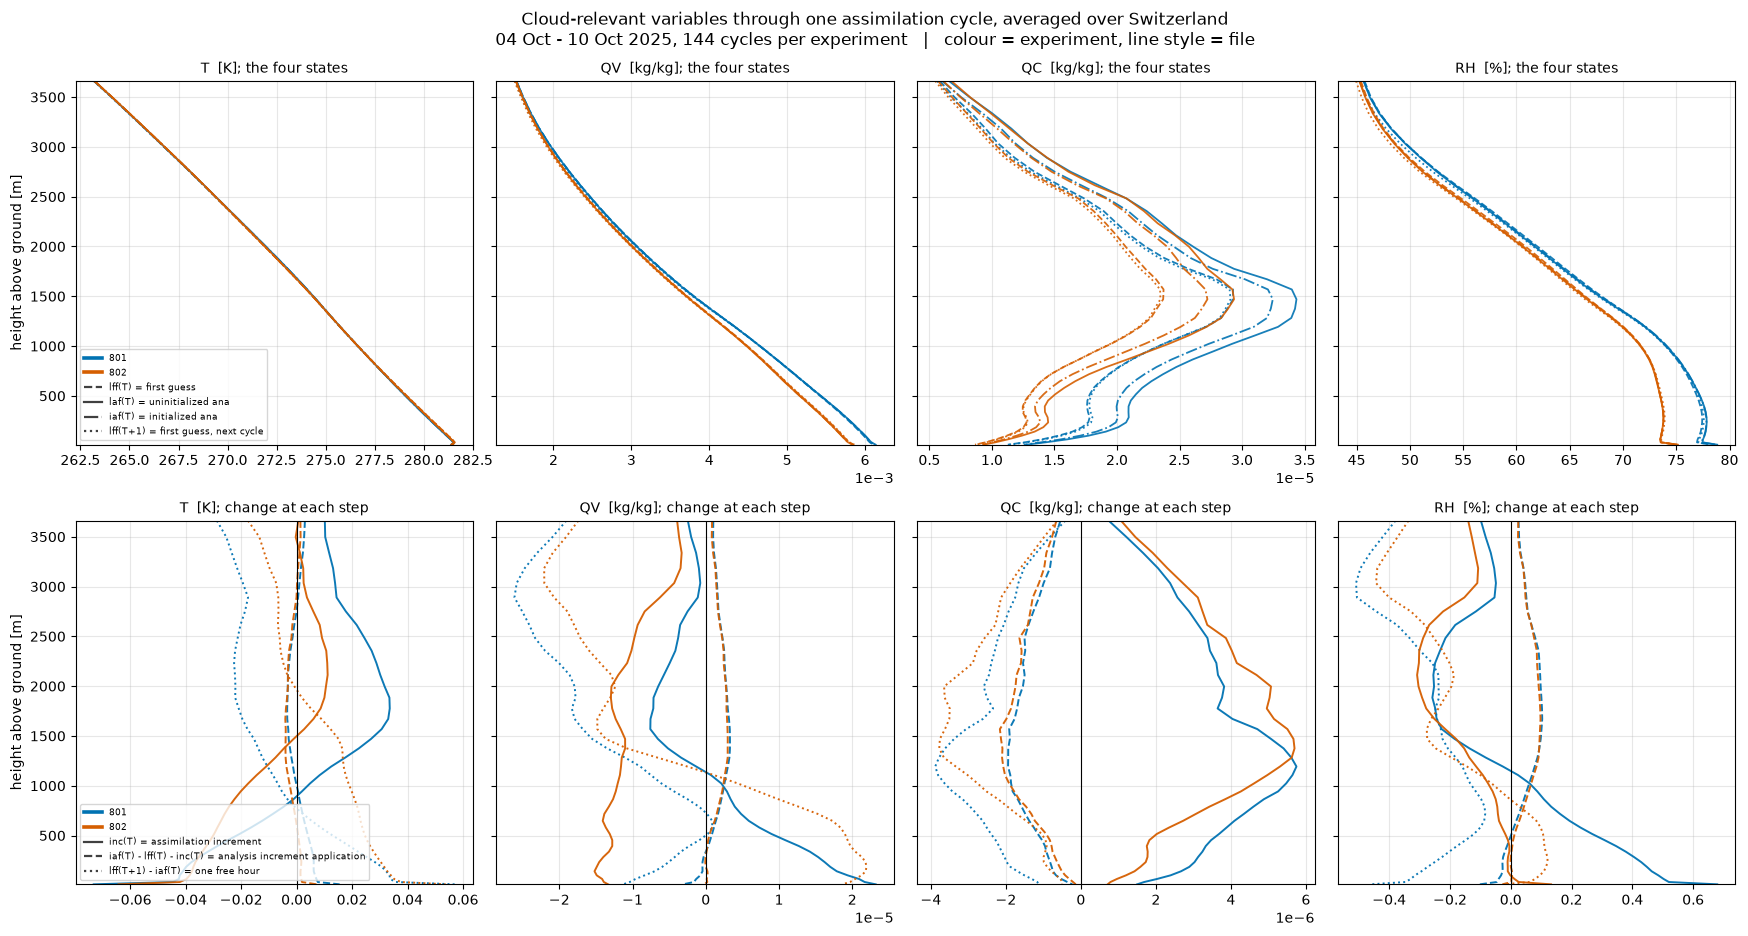

In [12]:
# Top row: the four states. Bottom row: the three steps between them.
fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(4.4 * len(PLOT_VARS), 9.5), sharey=True)

for col, var in enumerate(PLOT_VARS):
    ax = axes[0, col]
    for exp_id in EXP_IDS:
        for stage in STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(state_prof[(exp_id, stage, var)], z_prof, ls,
                    color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.9)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; the four states", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, z_prof)

    ax = axes[1, col]
    for exp_id in EXP_IDS:
        for term in TERMS:
            ls, _ = TERM_STYLE[term]
            ax.plot(term_prof[(exp_id, term, var)], z_prof, ls,
                    color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.95)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; change at each step", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, z_prof)

axes[0, 0].set_ylabel(HEIGHT_LABEL)
axes[1, 0].set_ylabel(HEIGHT_LABEL)
style_legend(axes[0, 0], STAGE_STYLE, fontsize=6.5, loc="lower left")
style_legend(axes[1, 0], TERM_STYLE, fontsize=6.5, loc="lower left")
plt.suptitle("Cloud-relevant variables through one assimilation cycle, averaged over Switzerland\n"
             f"{period_tag(n_cycles)}   |   colour = experiment, line style = file")
plt.tight_layout()
finish(fig, "cycle_variables_profiles.png")


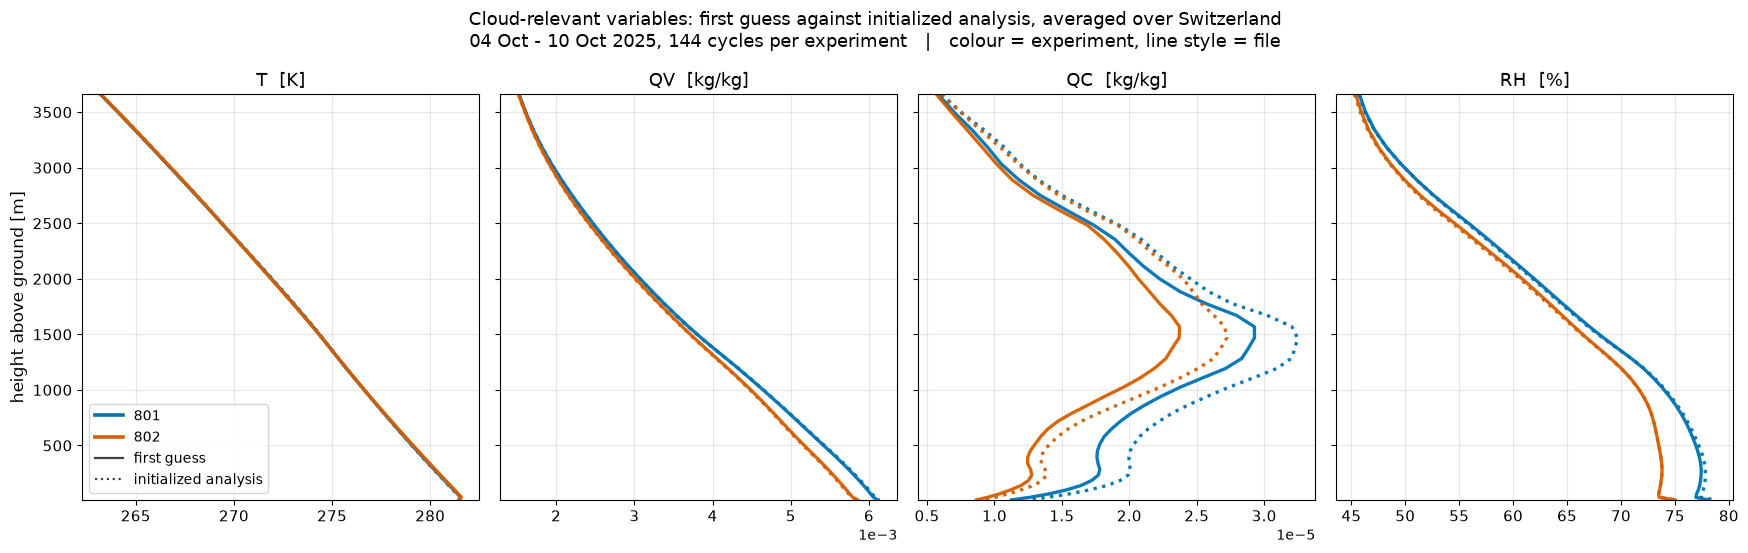

In [20]:
# Presentation version of the figure above: states row only, and only the two files a
# slide can carry - first guess and initialized analysis. One-off; the figure above
# stays the reference version.
SLIDE_STAGES = ["lff", "iaf"]
SLIDE_STYLE = {"lff": ("-", "first guess"), "iaf": (":", "initialized analysis")}

fig, axes = plt.subplots(1, len(PLOT_VARS), figsize=(4.4 * len(PLOT_VARS), 5.6), sharey=True)

for col, var in enumerate(PLOT_VARS):
    ax = axes[col]
    for exp_id in EXP_IDS:
        for stage in SLIDE_STAGES:
            ls, _ = SLIDE_STYLE[stage]
            ax.plot(state_prof[(exp_id, stage, var)], z_prof, ls,
                    color=EXP_COLOUR[exp_id], lw=2.4, alpha=0.95)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]", fontsize=13)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=11)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, z_prof)

axes[0].set_ylabel(HEIGHT_LABEL, fontsize=12)
style_legend(axes[0], SLIDE_STYLE, fontsize=10, loc="lower left")
plt.suptitle("Cloud-relevant variables: first guess against initialized analysis, "
             "averaged over Switzerland\n"
             f"{period_tag(n_cycles)}   |   colour = experiment, line style = file",
             fontsize=13)
plt.tight_layout()
finish(fig, "cycle_variables_profiles_slide.png")


## 2b. The same states at Payerne, against the radiosonde

In [14]:
SOUNDINGS_DIR = Path("/scratch/mch/jdelbeke/soundings/output")
STATION_ID = "06610"
SND_MISSING = 10000000          # per-field sentinel in the DWH sounding files
PAYERNE_ELEV_M = 490.0          # station altitude, from the sounding file header
SND_PLOT_VARS = ["T", "RH"]     # the only two variables the radiosonde also measures
SND_Z_TOP = 3000.0              # height window [m above ground]; None = every level read

# DWH numeric parameter IDs. No RH column: it is derived from the dew point below.
SND_COLS = {"742": "height", "745": "temperature", "747": "dewpoint", "744": "pressure"}


def read_sounding_day(day):
    """One day's raw file: every launch, every level. Header on line 2, data from line 4."""
    path = SOUNDINGS_DIR / f"{day:%Y%m%d}_{STATION_ID}_data.txt"
    with open(path) as f:
        header = f.readlines()[1].split()
    df = pd.read_csv(path, sep=r"\s*\|\s*", engine="python",
                     skiprows=3, header=None, names=header)
    # level = -100 is a header row (742 = 85 m, 744 = 1000 hPa, everything else sentinel).
    return df[df["level"] >= 0]


def sounding_profile(df, termin):
    """One launch as T [K], RH [%] and height above the launch site [m]."""
    one = df[df["termin"].astype("int64") == int(termin)]
    if one.empty:
        return None
    prof = (one[list(SND_COLS)].replace(SND_MISSING, np.nan).rename(columns=SND_COLS)
            .dropna(subset=["height", "temperature", "pressure"])   # dewpoint may stay NaN
            .sort_values("height").groupby("height", as_index=False).mean())
    if prof.empty:
        return None
    z = prof["height"].to_numpy()
    p_pa = prof["pressure"].to_numpy() * 100.0
    T_k = prof["temperature"].to_numpy() + 273.15
    # qsat at the dew point is the actual qv, so both sides share one saturation_qv.
    qv = saturation_qv(prof["dewpoint"].to_numpy() + 273.15, p_pa)
    return pd.DataFrame({"z_agl": z - z[0], "T": T_k,
                         "RH": 100.0 * qv / saturation_qv(T_k, p_pa)})


def match_sounding_cycles(cycle_times):
    """The inner join: cycles whose nominal hour has a Payerne launch, plus the day files."""
    frames, available = {}, set()
    for day in sorted({pd.Timestamp(t).normalize() for t in cycle_times}):
        try:
            frames[day] = read_sounding_day(day)
        except FileNotFoundError:
            print(f"  no sounding file for {day:%Y-%m-%d}")
            continue
        available |= set(frames[day]["termin"].astype("int64").unique())
    matched = [t for t in cycle_times if int(f"{t:%Y%m%d%H}0000") in available]
    return matched, frames


def payerne_states(exp_id, t, cell, levels=LEVELS_OF_INTEREST):
    """The four states of one cycle in one column: T [K] and derived RH [%].

    laf(T) = lff(T) + inc(T) as in section 2 (exact to ~2e-4 K). RH is formed per stage,
    being non-linear in T and QV.
    """
    lff = Grib(file_path(exp_id, "lff", t))
    inc = Grib(file_path(exp_id, "inc", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lff1 = Grib(file_path(exp_id, "lff", t + timedelta(hours=1)))

    def col(grib, var):
        return grib.profile(var, levels)[1][:, cell]

    out = {}
    for var in ("T", "QV", "P"):
        a_lff, a_inc = col(lff, var), col(inc, var)
        out[("lff", var)] = a_lff
        out[("laf", var)] = a_lff + a_inc
        out[("iaf", var)] = col(iaf, var)
        out[("lff1", var)] = col(lff1, var)
    for stage in STAGES:
        out[(stage, "RH")] = 100.0 * out[(stage, "QV")] / saturation_qv(out[(stage, "T")],
                                                                       out[(stage, "P")])
    return {(s, v): out[(s, v)] for s in STAGES for v in SND_PLOT_VARS}


def sounding_on_model_layers(values, obs_z, bounds):
    """Average the sounding over each model layer; NaN where a layer holds no level.

    `bounds` is top-first, so layer k runs from bounds[k+1] (base) up to bounds[k] (top).
    """
    values = np.asarray(values, dtype=float)
    means = np.full(len(bounds) - 1, np.nan)
    counts = np.zeros(len(bounds) - 1, dtype=int)
    for k in range(len(bounds) - 1):
        # half-open at the top: a level on a shared interface is counted once
        sel = (obs_z >= bounds[k + 1]) & (obs_z < bounds[k]) & np.isfinite(values)
        counts[k] = int(sel.sum())
        if counts[k]:
            means[k] = values[sel].mean()
    return means, counts


def _payerne_job(job):
    """One (experiment, cycle) read, for the process pool."""
    exp_id, t = job
    try:
        return exp_id, t, payerne_states(exp_id, t, PAY_CELL)
    except Exception as e:
        print(f"  skipped {exp_id} {t:%Y-%m-%d %H}: {type(e).__name__}: {e}", flush=True)
        return exp_id, t, None


# ---- the Payerne column geometry ----
# HHL is re-read because load_geometry keeps only layer centres, and the sounding has to be
# averaged between the layer *bounds*.
PAY_CELL = int(nearest_cells(geom["lon"], geom["lat"],
                             np.array([PAYERNE[1]]), np.array([PAYERNE[0]]))[0])
_pay_hhl = Grib(file_path(EXP_IDS[0], "iaf", CYCLE_TIMES[0])).profile(
    "HHL", range(int(min(LEVELS_OF_INTEREST)), int(max(LEVELS_OF_INTEREST)) + 2))[1][:, PAY_CELL]
hsurf_pay = float(geom["hsurf"][PAY_CELL])
# Above ground, so column and sounding share a zero. Not the same axis as z_prof above.
z_bounds_pay = _pay_hhl - hsurf_pay
z_pay = 0.5 * (z_bounds_pay[:-1] + z_bounds_pay[1:])
z_top_pay = z_pay.max() if SND_Z_TOP is None else SND_Z_TOP

_d_km = 6371.0 * np.arccos(np.clip(
    np.sin(np.deg2rad(PAYERNE[0])) * np.sin(np.deg2rad(geom["lat"][PAY_CELL])) +
    np.cos(np.deg2rad(PAYERNE[0])) * np.cos(np.deg2rad(geom["lat"][PAY_CELL])) *
    np.cos(np.deg2rad(geom["lon"][PAY_CELL] - PAYERNE[1])), -1, 1))
print(f"Payerne cell {PAY_CELL}: {_d_km * 1000:.0f} m from the station, "
      f"model terrain {hsurf_pay:.1f} m against the station's {PAYERNE_ELEV_M:.0f} m "
      f"({hsurf_pay - PAYERNE_ELEV_M:+.1f} m)")

# ---- the inner join ----
snd_times, snd_frames = match_sounding_cycles(CYCLE_TIMES)
print(f"{len(snd_times)} of {len(CYCLE_TIMES)} cycles have a Payerne launch: "
      f"{', '.join(f'{t:%d %b %H}' for t in snd_times)}")

# ---- the sounding, averaged onto the model layers ----
obs_by_time, obs_counts = {}, []
for t in snd_times:
    prof = sounding_profile(snd_frames[pd.Timestamp(t).normalize()], f"{t:%Y%m%d%H}0000")
    if prof is None:
        print(f"  launch {t:%d %b %H} present in the file but has no usable levels")
        continue
    per_var = {}
    for var in SND_PLOT_VARS:
        per_var[var], counts = sounding_on_model_layers(prof[var].to_numpy(),
                                                        prof["z_agl"].to_numpy(), z_bounds_pay)
        if var == SND_PLOT_VARS[0]:
            obs_counts.append(counts)
    obs_by_time[t] = per_var

snd_times = [t for t in snd_times if t in obs_by_time]
_win = z_pay <= z_top_pay
_c = np.array(obs_counts)[:, _win]
print(f"{len(snd_times)} usable soundings; sounding levels per model layer in the window: "
      f"min {_c.min()}, median {int(np.median(_c))}, max {_c.max()}")
if _c.min() == 0:
    print("note: some layer/launch combinations hold no sounding level and are left as gaps")

# ---- the model, in parallel ----
jobs = [(e, t) for e in EXP_IDS for t in snd_times]
print(f"\nreading {len(jobs)} cycle-experiment combinations on {N_WORKERS} workers")

pay_state, pay_dev_by_cycle, n_pay = {}, {}, {e: 0 for e in EXP_IDS}
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    for exp_id, t, res in ex.map(_payerne_job, jobs):
        if res is None:
            continue
        for (stage, var), values in res.items():
            pay_state.setdefault((exp_id, stage, var), []).append(values)
            # kept per cycle, so the mean below averages deviations rather than differencing means
            pay_dev_by_cycle.setdefault((exp_id, stage, var), []).append(
                values - obs_by_time[t][var])
        n_pay[exp_id] += 1

pay_state = {k: np.mean(v, axis=0) for k, v in pay_state.items()}
pay_dev_by_cycle = {k: np.array(v) for k, v in pay_dev_by_cycle.items()}   # (launch, level)
pay_dev = {k: np.nanmean(v, axis=0) for k, v in pay_dev_by_cycle.items()}  # for the figure
obs_mean = {var: np.nanmean([obs_by_time[t][var] for t in snd_times], axis=0)
            for var in SND_PLOT_VARS}
n_snd = min(n_pay.values())
print(f"done: {n_pay} sounding-matched cycles per experiment")

Payerne cell 746375: 274 m from the station, model terrain 468.6 m against the station's 490 m (-21.4 m)
12 of 144 cycles have a Payerne launch: 04 Oct 12, 05 Oct 00, 05 Oct 12, 06 Oct 00, 06 Oct 12, 07 Oct 00, 07 Oct 12, 08 Oct 00, 08 Oct 12, 09 Oct 00, 09 Oct 12, 10 Oct 00
12 usable soundings; sounding levels per model layer in the window: min 1, median 17, max 33

reading 24 cycle-experiment combinations on 16 workers
done: {'801': 12, '802': 12} sounding-matched cycles per experiment


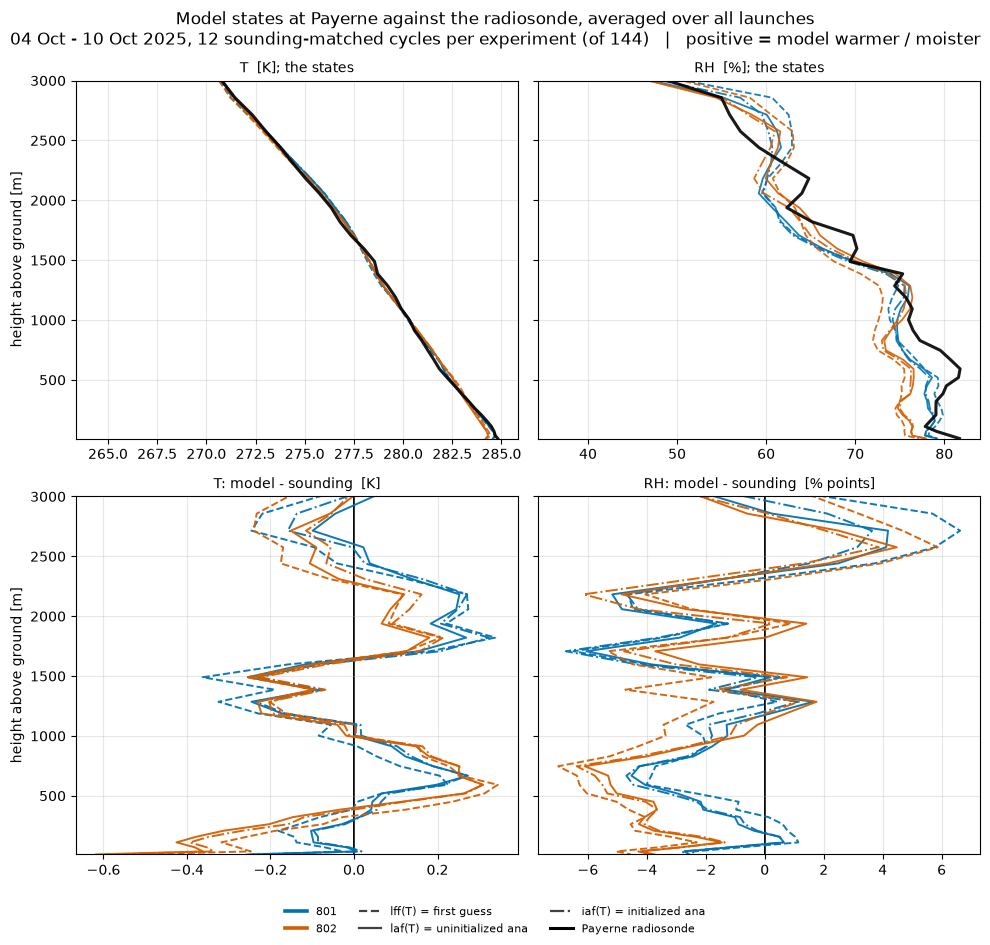

In [15]:
# Top row: the states in the Payerne column against the sounding. Bottom row: each file's
# deviation from it. lff(T+1) is left out to keep the panels readable.
DEV_UNITS = {"T": "K", "RH": "% points"}
PAY_STAGES = [s for s in STAGES if s != "lff1"]

fig, axes = plt.subplots(2, len(SND_PLOT_VARS),
                         figsize=(5.0 * len(SND_PLOT_VARS), 9.5), sharey=True)

for col, var in enumerate(SND_PLOT_VARS):
    ax = axes[0, col]
    for exp_id in EXP_IDS:
        for stage in PAY_STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(pay_state[(exp_id, stage, var)], z_pay, ls,
                    color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.9)
    ax.plot(obs_mean[var], z_pay, "-", color="k", lw=2.2, alpha=0.9, zorder=5)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; the states", fontsize=10)
    ax.grid(alpha=0.3)
    orient_vertical(ax, z_pay)
    ax.set_ylim(np.min(z_pay), z_top_pay)

    ax = axes[1, col]
    for exp_id in EXP_IDS:
        for stage in PAY_STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(pay_dev[(exp_id, stage, var)], z_pay, ls,
                    color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.95)
    ax.axvline(0, color="k", lw=1.4, zorder=1)      # the sounding, by construction
    ax.set_title(f"{var}: model - sounding  [{DEV_UNITS[var]}]", fontsize=10)
    ax.grid(alpha=0.3)
    orient_vertical(ax, z_pay)
    ax.set_ylim(np.min(z_pay), z_top_pay)

axes[0, 0].set_ylabel(HEIGHT_LABEL)
axes[1, 0].set_ylabel(HEIGHT_LABEL)

# style_legend cannot carry the sounding, so the handles are built here.
_handles = [Line2D([], [], color=EXP_COLOUR[e], ls="-", lw=2.6, label=e) for e in EXP_IDS]
_handles += [Line2D([], [], color="0.25", ls=STAGE_STYLE[s][0], lw=1.6,
                    label=STAGE_STYLE[s][1]) for s in PAY_STAGES]
_handles += [Line2D([], [], color="k", ls="-", lw=2.2, label="Payerne radiosonde")]
fig.legend(handles=_handles, loc="lower center", ncol=3, frameon=False, fontsize=8)

plt.suptitle("Model states at Payerne against the radiosonde, averaged over all launches\n"
             f"{DATE_START:%d %b} - {DATE_END:%d %b %Y}, {n_snd} sounding-matched cycles "
             f"per experiment (of {len(CYCLE_TIMES)})   |   "
             "positive = model warmer / moister")
plt.tight_layout(rect=(0, 0.05, 1, 1))
finish(fig, "payerne_sounding_profiles.png")

## 3. Does the assimilation push air past saturation?

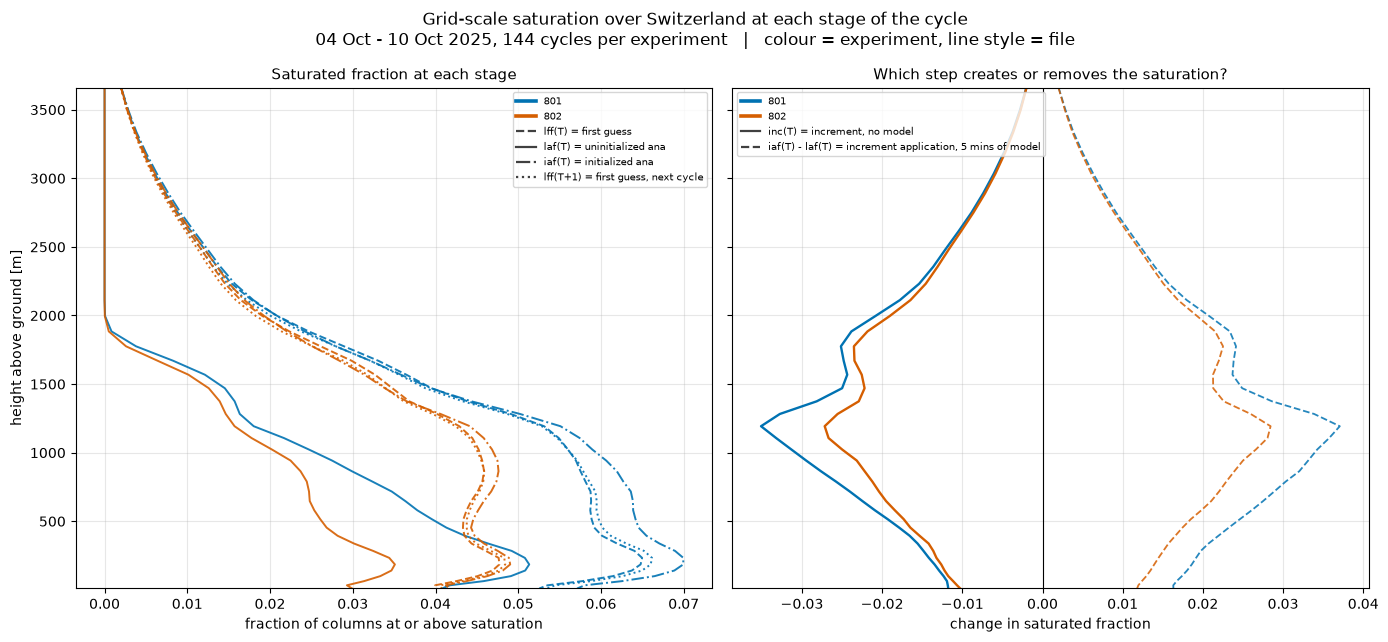

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)

for exp_id in EXP_IDS:
    for stage in STAGES:
        ls, _ = STAGE_STYLE[stage]
        axes[0].plot(sat_frac[(exp_id, stage)], z_prof, ls,
                     color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.9)
axes[0].set_xlabel("fraction of columns at or above saturation")
axes[0].set_ylabel(HEIGHT_LABEL)
axes[0].set_title("Saturated fraction at each stage", fontsize=11)
axes[0].grid(alpha=0.3)
style_legend(axes[0], STAGE_STYLE, fontsize=7, loc="upper right")

# Split into the assimilation-only part and the analysis increment application part.
SPLIT_STYLE = {
    "assim":  ("-",  "inc(T) = increment, no model"),
    "settle": ("--", "iaf(T) - laf(T) = increment application, 5 mins of model"),
}
for exp_id in EXP_IDS:
    axes[1].plot(sat_frac[(exp_id, "laf")] - sat_frac[(exp_id, "lff")], z_prof,
                 SPLIT_STYLE["assim"][0], color=EXP_COLOUR[exp_id], lw=1.7)
    axes[1].plot(sat_frac[(exp_id, "iaf")] - sat_frac[(exp_id, "laf")], z_prof,
                 SPLIT_STYLE["settle"][0], color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.85)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("change in saturated fraction")
axes[1].set_title("Which step creates or removes the saturation?", fontsize=11)
axes[1].grid(alpha=0.3)
style_legend(axes[1], SPLIT_STYLE, fontsize=7, loc="upper left")

for ax in axes:
    orient_vertical(ax, z_prof)
plt.suptitle("Grid-scale saturation over Switzerland at each stage of the cycle\n"
             f"{period_tag(n_cycles)}   |   colour = experiment, line style = file")
plt.tight_layout()
finish(fig, "saturation_by_stage.png")


## 4. Where in space does the assimilation put its corrections?

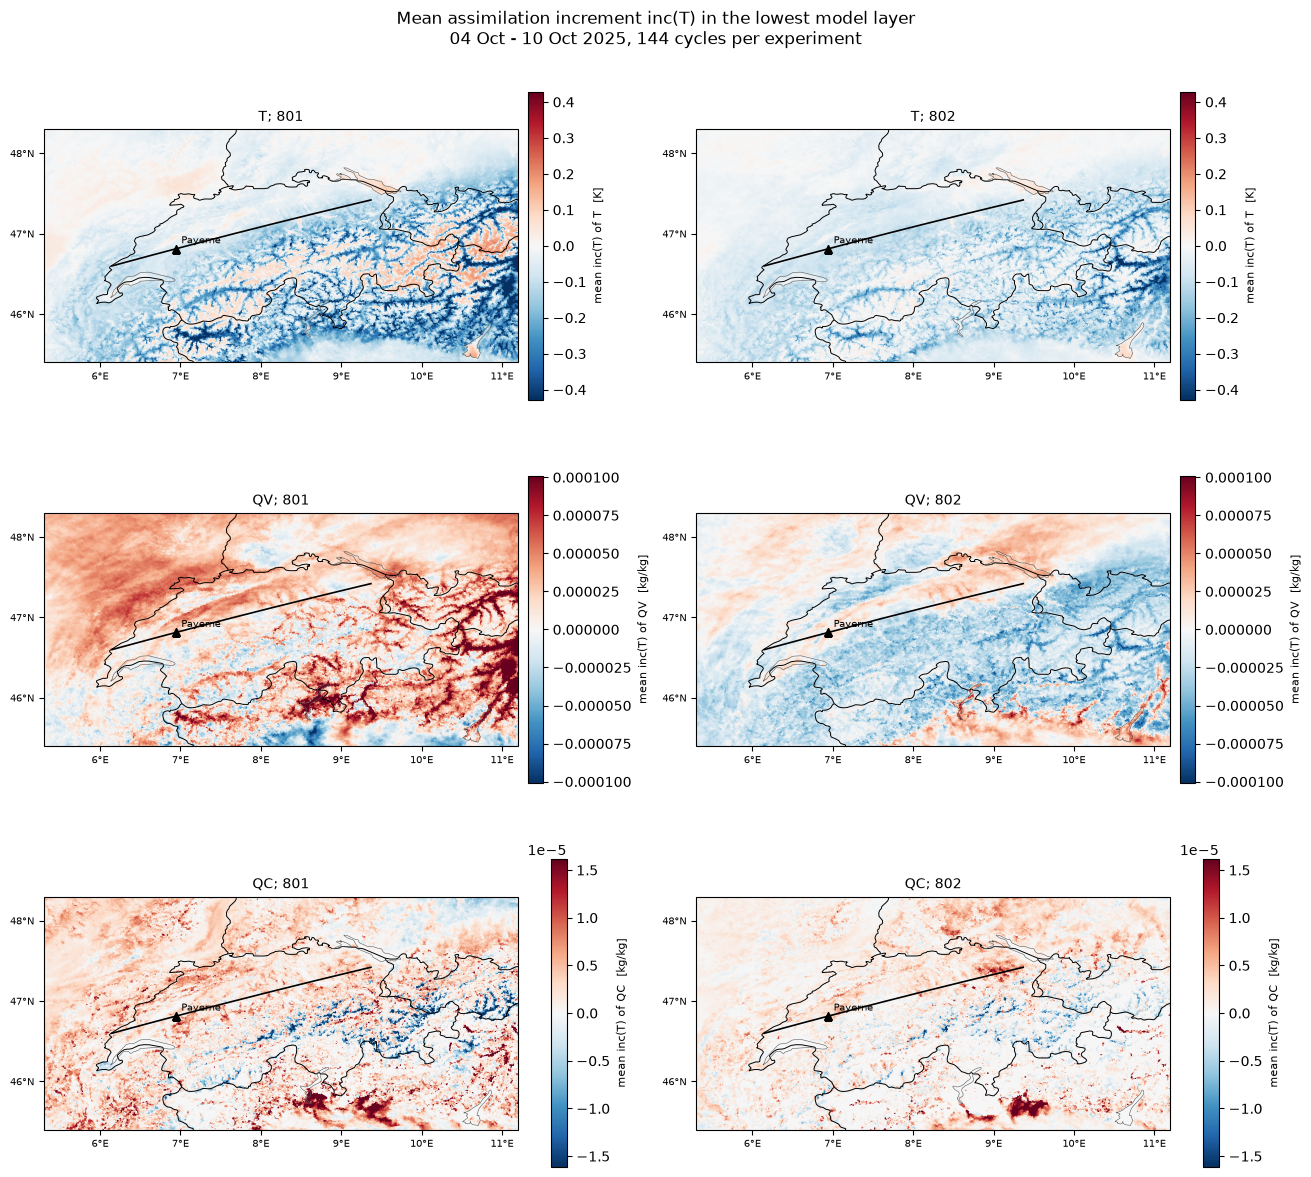

In [17]:
def sym_limit(arrays, pct=99.0):
    """One symmetric colour limit shared across panels, so magnitudes stay comparable."""
    vals = np.concatenate([np.abs(a[np.isfinite(a)]).ravel() for a in arrays])
    v = np.nanpercentile(vals, pct) if vals.size else 1.0
    return v if v > 0 else 1.0


# ---------------------- 4a. lowest model layer, with borders ----------------------
mbox = in_box(geom["lon"], geom["lat"], MAP_BOX)
mlon, mlat = geom["lon"][mbox], geom["lat"][mbox]

fig, axes = plt.subplots(len(DIAG_VARS), len(EXP_IDS), figsize=(13, 12),
                         subplot_kw={"projection": ccrs.PlateCarree()},
                         constrained_layout=True)
for r, var in enumerate(DIAG_VARS):
    vlim = sym_limit([inc_ground[(e, var)][mbox] for e in EXP_IDS])
    for c, exp_id in enumerate(EXP_IDS):
        ax = axes[r, c]
        sc = ax.scatter(mlon, mlat, c=inc_ground[(exp_id, var)][mbox], s=1.6,
                        cmap="RdBu_r", vmin=-vlim, vmax=vlim, linewidths=0,
                        transform=ccrs.PlateCarree())
        ax.set_extent([MAP_BOX["lon"][0], MAP_BOX["lon"][1],
                       MAP_BOX["lat"][0], MAP_BOX["lat"][1]], crs=ccrs.PlateCarree())
        add_borders(ax)
        ax.plot(lon_t, lat_t, "k-", lw=1.2, transform=ccrs.PlateCarree())
        ax.plot(*PAYERNE[::-1], "k^", ms=6, transform=ccrs.PlateCarree())
        ax.annotate("Payerne", xy=PAYERNE[::-1], xytext=(4, 4), textcoords="offset points",
                    fontsize=7, transform=ccrs.PlateCarree())
        cb = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
        cb.set_label(f"mean inc(T) of {var}  [{VAR_UNITS[var]}]", fontsize=8)
        ax.set_title(f"{var}; {exp_id}", fontsize=10)
        # explicit ticks rather than gridlines(draw_labels=...): the labelled gridliner
        # clashes with a tight bounding box on cartopy axes
        ax.set_xticks(np.arange(6, 12, 1), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(46, 49, 1), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=7)

plt.suptitle("Mean assimilation increment inc(T) in the lowest model layer\n"
             f"{period_tag(n_cycles)}")
finish(fig, "increment_map_ground_level.png")


section length 261 km; Payerne at 65 km along it, 0.4 km off the line


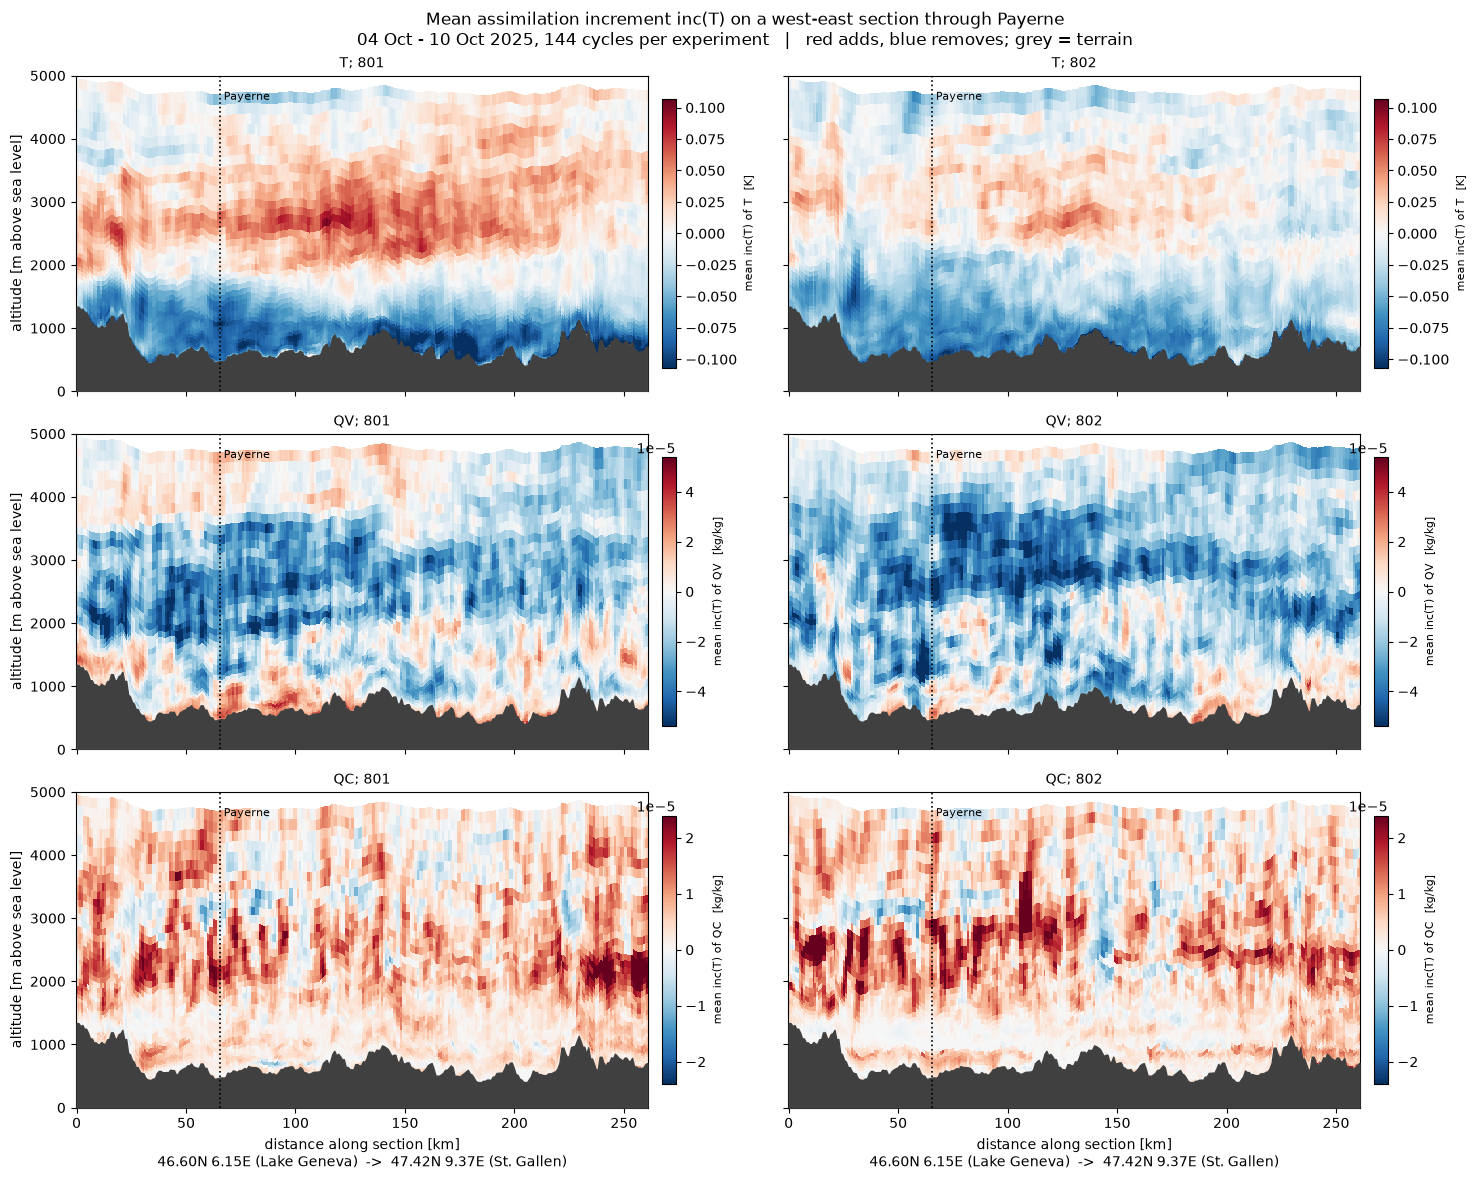

In [18]:
# ---------------------- 4b. vertical section through Payerne ----------------------
z_sec = geom["z"][:, geom["t_idx"]]
terrain = geom["hsurf"][geom["t_idx"]]
dist2d = np.broadcast_to(dist_t, z_sec.shape)

# where Payerne sits along the section
d_pay = np.hypot(np.deg2rad(lat_t - PAYERNE[0]) * 6371.0,
                 np.deg2rad(lon_t - PAYERNE[1]) * 6371.0 * np.cos(np.deg2rad(PAYERNE[0])))
i_pay = int(np.argmin(d_pay))
print(f"section length {dist_t[-1]:.0f} km; Payerne at {dist_t[i_pay]:.0f} km "
      f"along it, {d_pay[i_pay]:.1f} km off the line")

fig, axes = plt.subplots(len(DIAG_VARS), len(EXP_IDS), figsize=(15, 12),
                         sharex=True, sharey=True)
for r, var in enumerate(DIAG_VARS):
    vlim = sym_limit([inc_section[(e, var)] for e in EXP_IDS])
    for c, exp_id in enumerate(EXP_IDS):
        ax = axes[r, c]
        pc = ax.pcolormesh(dist2d, z_sec, inc_section[(exp_id, var)], shading="auto",
                           cmap="RdBu_r", vmin=-vlim, vmax=vlim)
        ax.fill_between(dist_t, 0, terrain, color="0.25", zorder=5)
        ax.axvline(dist_t[i_pay], color="k", ls=":", lw=1.2, zorder=6)
        ax.text(dist_t[i_pay], SECTION_ZTOP * 0.95, " Payerne", fontsize=8,
                va="top", ha="left", zorder=7)
        cb = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.02)
        cb.set_label(f"mean inc(T) of {var}  [{VAR_UNITS[var]}]", fontsize=8)
        ax.set_title(f"{var}; {exp_id}", fontsize=10)
        ax.set_ylim(0, SECTION_ZTOP)
        if r == len(DIAG_VARS) - 1:
            ax.set_xlabel(f"distance along section [km]\n"
                          f"{TRANSECT[0][0]:.2f}N {TRANSECT[0][1]:.2f}E (Lake Geneva)"
                          f"  ->  {TRANSECT[1][0]:.2f}N {TRANSECT[1][1]:.2f}E (St. Gallen)")
        if c == 0:
            ax.set_ylabel("altitude [m above sea level]")

plt.suptitle("Mean assimilation increment inc(T) on a west-east section through Payerne\n"
             f"{period_tag(n_cycles)}   |   red adds, blue removes; grey = terrain")
plt.tight_layout()
finish(fig, "increment_section_payerne.png")


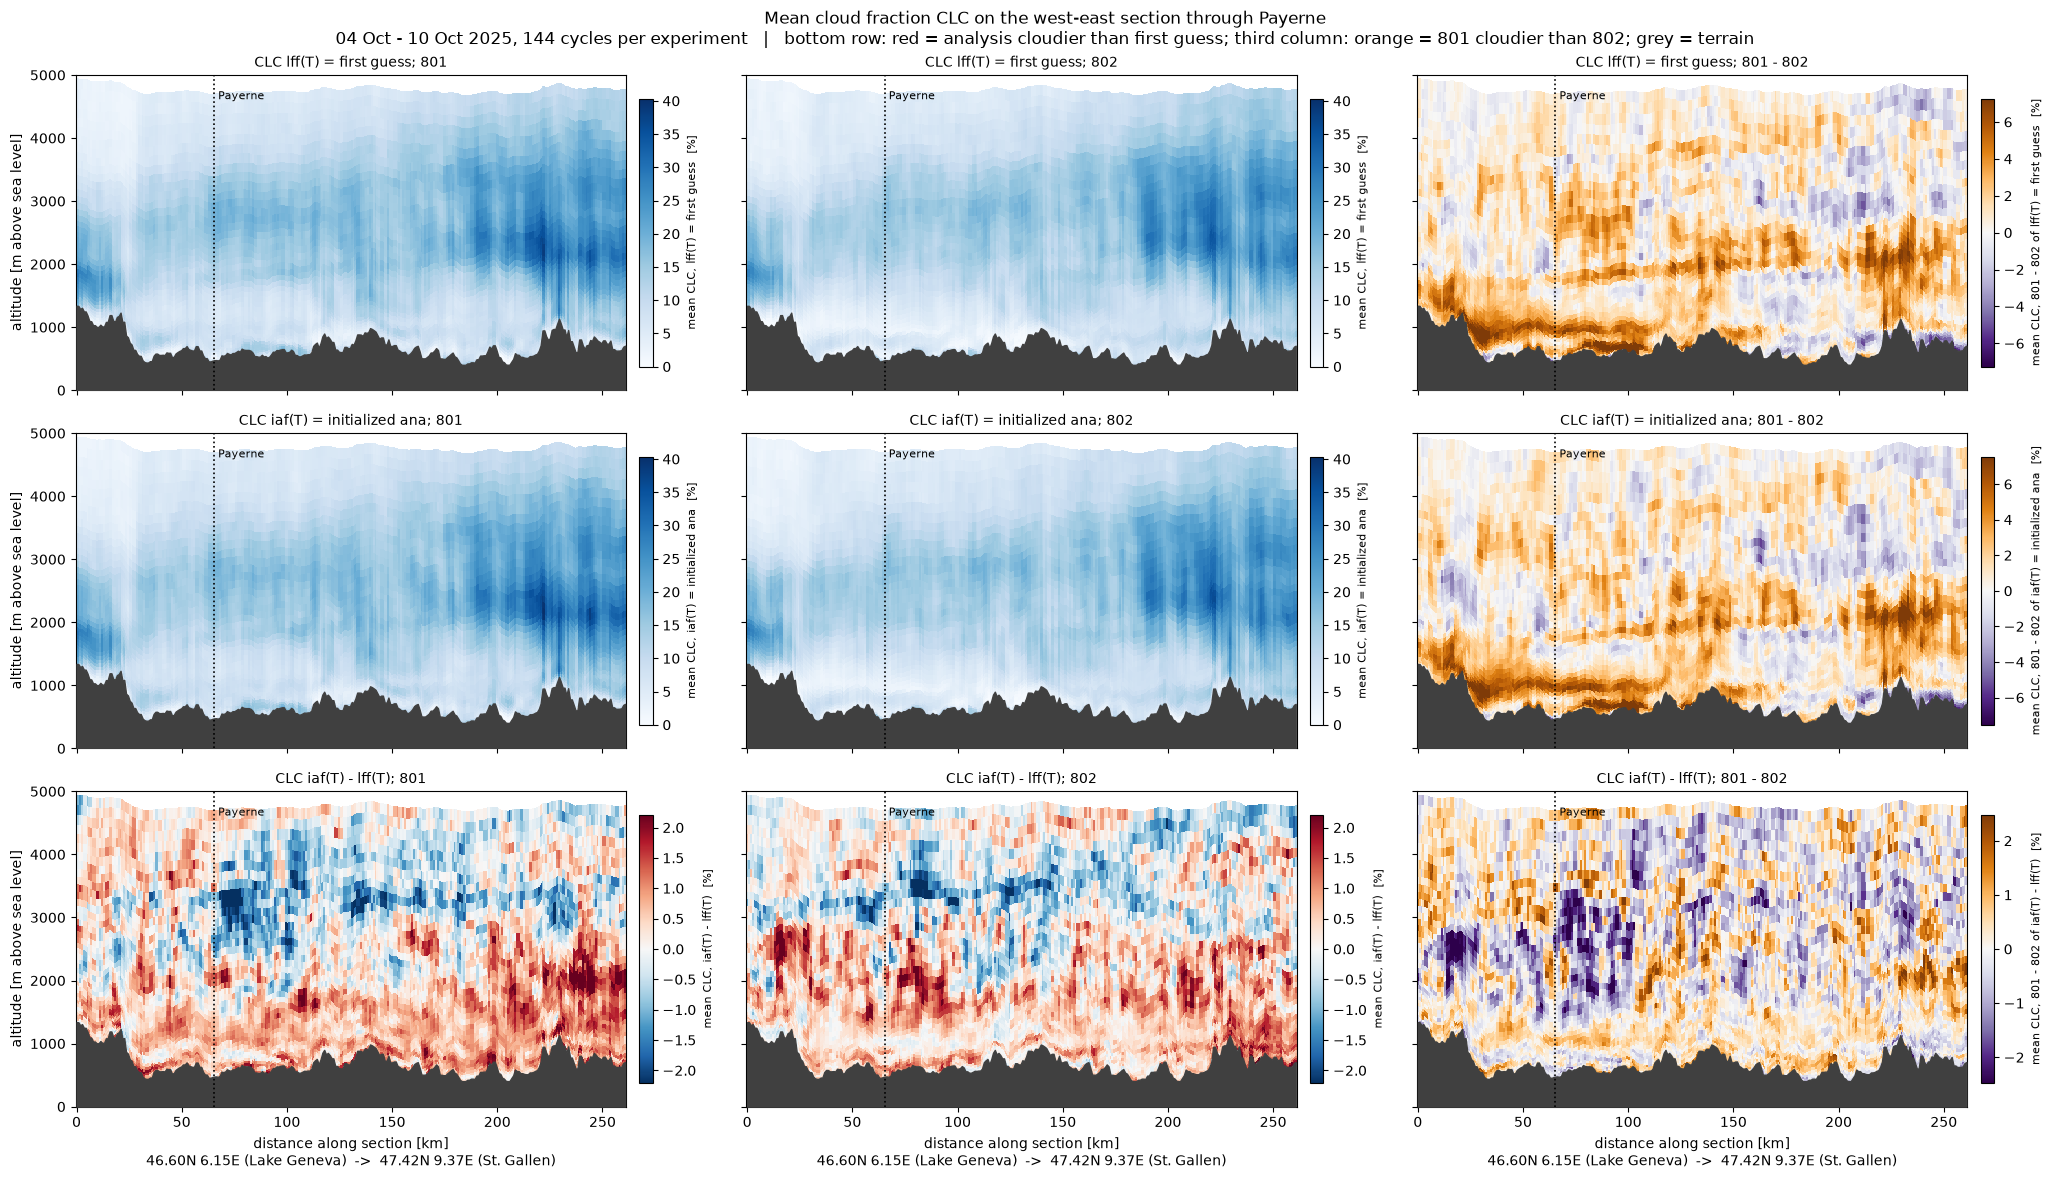

In [19]:
# ---------------------- 4c. cloud fraction on the same section ----------------------
# The same transect as 4b, for CLC rather than an increment. Two states and their
# difference: iaf(T) - lff(T) is not the assimilation alone, since CLC is diagnosed and
# the 10 minutes of model integration inside iaf(T) have already acted on it.
CLC_ROWS = [("lff", "lff(T) = first guess"),
            ("iaf", "iaf(T) = initialized ana"),
            ("diff", "iaf(T) - lff(T)")]
EXP_DIFF = f"{EXP_IDS[0]} - {EXP_IDS[1]}"       # third column: the experiments differenced
CLC_COLS = EXP_IDS + [EXP_DIFF]


def clc_field(row, exp_id):
    """One row of the figure for one experiment; rows differ only in which states they take."""
    if row == "diff":
        return clc_section[(exp_id, "iaf")] - clc_section[(exp_id, "lff")]
    return clc_section[(exp_id, row)]


# Colour limits, fixed per row before plotting. The two experiment columns share one scale
# so they can be compared directly. The third column gets its own symmetric scale per row
# and a different diverging map: in the bottom row it is a difference of differences, an
# order of magnitude smaller than the states above, so sharing a scale would hide it.
state_vmax = max(np.nanmax(clc_section[(e, s)]) for e in EXP_IDS for s in CLC_STAGES)
row_kw, diff_kw = {}, {}
for row, _ in CLC_ROWS:
    if row == "diff":
        v = sym_limit([clc_field(row, e) for e in EXP_IDS])
        row_kw[row] = dict(cmap="RdBu_r", vmin=-v, vmax=v)
    else:
        row_kw[row] = dict(cmap="Blues", vmin=0, vmax=state_vmax)
    vd = sym_limit([clc_field(row, EXP_IDS[0]) - clc_field(row, EXP_IDS[1])])
    diff_kw[row] = dict(cmap="PuOr_r", vmin=-vd, vmax=vd)

fig, axes = plt.subplots(len(CLC_ROWS), len(CLC_COLS), figsize=(21, 12),
                         sharex=True, sharey=True)
for r, (row, row_label) in enumerate(CLC_ROWS):
    for c, col in enumerate(CLC_COLS):
        ax = axes[r, c]
        if col == EXP_DIFF:
            field = clc_field(row, EXP_IDS[0]) - clc_field(row, EXP_IDS[1])
            kw, cb_label = diff_kw[row], f"{EXP_DIFF} of {row_label}"
        else:
            field, kw, cb_label = clc_field(row, col), row_kw[row], row_label
        pc = ax.pcolormesh(dist2d, z_sec, field, shading="auto", **kw)
        ax.fill_between(dist_t, 0, terrain, color="0.25", zorder=5)
        ax.axvline(dist_t[i_pay], color="k", ls=":", lw=1.2, zorder=6)
        ax.text(dist_t[i_pay], SECTION_ZTOP * 0.95, " Payerne", fontsize=8,
                va="top", ha="left", zorder=7)
        cb = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.02)
        cb.set_label(f"mean CLC, {cb_label}  [%]", fontsize=8)
        ax.set_title(f"CLC {row_label}; {col}", fontsize=10)
        ax.set_ylim(0, SECTION_ZTOP)
        if r == len(CLC_ROWS) - 1:
            ax.set_xlabel(f"distance along section [km]\n"
                          f"{TRANSECT[0][0]:.2f}N {TRANSECT[0][1]:.2f}E (Lake Geneva)"
                          f"  ->  {TRANSECT[1][0]:.2f}N {TRANSECT[1][1]:.2f}E (St. Gallen)")
        if c == 0:
            ax.set_ylabel("altitude [m above sea level]")

plt.suptitle("Mean cloud fraction CLC on the west-east section through Payerne\n"
             f"{period_tag(n_cycles)}   |   bottom row: red = analysis cloudier than first "
             f"guess; third column: orange = {EXP_IDS[0]} cloudier than {EXP_IDS[1]}; "
             "grey = terrain")
plt.tight_layout()
finish(fig, "clc_section_payerne.png")


## 5. Summary

### Output files

All written to `figures/spindown_decomposition/`.

| file | contents |
|---|---|
| `diurnal_boxplots.png` | cloud cover by hour of day; both experiments, first guess against analysis |
| `cloud_cover_timeseries.png` | mean cloud cover through the period |
| `cycle_variables_profiles.png` | T, QV, QC, RH: the four states and the three steps |
| `payerne_sounding_profiles.png` | T and RH at Payerne against the radiosonde, and the deviation |
| `saturation_by_stage.png` | saturated fraction, and which step changes it |
| `increment_map_ground_level.png` | mean increment in the lowest layer, with borders |
| `increment_section_payerne.png` | mean increment on a section through Payerne |
| `clc_section_payerne.png` | mean cloud fraction on that section, first guess against analysis |
| `cloud_cover_means.csv`, `water_budget_per_cycle.csv`, `water_budget_summary.csv` | the numbers behind the figures |